# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [127]:
# Import warnings
import warnings



In [128]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [129]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.4.4
pandas version: 3.0.3
matplotlib version: 3.10.9
seaborn version: 0.13.2


In [130]:
import sys
print(sys.executable)



/Users/farahuzma/PG IIITB/NYC Assignment/.venv/bin/python


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [312]:
import os
os.getcwd()
os.chdir('..')


In [313]:
# Try loading one file

# df = pd.read_parquet('2023-1.parquet')
# df.info()

df1 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-1.parquet')
df2 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-2.parquet')
df3 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-3.parquet')
df4 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-4.parquet')
df5 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-5.parquet')
df6 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-6.parquet')
df7 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-7.parquet')
df8 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-8.parquet')
df9 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-9.parquet')
df10 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-10.parquet')
df11 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-11.parquet')
df12 = pd.read_parquet('./Datasets and Dictionary/trip_records/2023-12.parquet')
print(df1.shape)
print(df2.shape)
print(df3.shape)
print(df4.shape)
print(df5.shape)
print(df6.shape)
print(df7.shape)
print(df8.shape)
print(df9.shape)
print(df10.shape)
print(df11.shape)
print(df12.shape)

(3041714, 19)
(3374086, 19)
(3275796, 19)
(2792901, 19)
(2889185, 19)
(3258261, 19)
(3481547, 19)
(2875947, 19)
(2817156, 19)
(3485185, 19)
(3302857, 19)
(3333925, 19)


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
import pandas as pd

def sample_by_date_hour(df, frac=0.1, seed=42):
    # Extract date and hour from pickup datetime
    df = df.copy()
    df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    
    # Group by (date, hour) and sample frac from each group
    sampled = df.groupby(['pickup_date', 'pickup_hour'], group_keys=False).apply(
        lambda g: g.sample(frac=frac, random_state=seed)
    )
    

    # Drop helper columns if you don't need them
    # sampled = sampled.drop(columns=['pickup_date', 'pickup_hour'])
    print("------")
    print(sampled.columns)
    return sampled

# Apply to all 12 dataframes
dfs = [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12]
temp = []
for df in dfs:
    x = sample_by_date_hour(df)
    temp.append(x)

sampled_data = pd.concat(temp, ignore_index=True)

# sampled_data = pd.concat([sample_by_date_hour(df) for df in dfs], ignore_index=True)

print(f"Original total: {sum(len(df) for df in dfs):,}")
print(f"Sampled total:  {len(sampled_data):,}")
print(f"Ratio: {len(sampled_data) / sum(len(df) for df in dfs):.4f}")


------
Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='str')
------
Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee'],
      dtype='str')
------
Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('./Datasets and Dictionary/trip_records')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()
frac = 0.05

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)
        df_temp = pd.read_parquet(file_path)
        df_temp = df_temp.copy()
        
        # Create two new columns: date and hour from the pickup datetime
        df_temp['pickup_date'] = df_temp['tpep_pickup_datetime'].dt.date
        df_temp['pickup_hour'] = df_temp['tpep_pickup_datetime'].dt.hour
        
        # This will hold all our sampled rows
        sampled_data = pd.DataFrame()
        
        # Get all unique dates in this dataframe
        unique_dates = df_temp['pickup_date'].unique()
        
        # Loop through dates and then loop through every hour of each date
        for date in unique_dates:
            # Iterate through each hour of the selected date
            for hour in range(24):
                # Filter rows for this specific date and hour
                hour_data = df_temp[(df_temp['pickup_date'] == date) & (df_temp['pickup_hour'] == hour)]
                
                # Skip if there's no data for this hour
                if len(hour_data) == 0:
                    continue
                
                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac=frac)
                
                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample])
        
        # Remove the helper columns we created
        sampled_data = sampled_data.drop(columns=['pickup_date', 'pickup_hour'])

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.

        df = pd.concat([df, sampled_data])

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

KeyboardInterrupt: 

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [ ]:
# Store the df in csv/parquet
# df.to_parquet('sampled_nyc_taxi_data.parquet', index=False)
# os.chdir('./Datasets and Dictionary/trip_records')
sampled_data.to_parquet('./sampled_nyc_taxi_data.parquet', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [132]:
# Load the new data file
df = pd.read_parquet('./sampled_nyc_taxi_data.parquet')

In [133]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.86,1.00,N,141,140,1,6.50,1.00,0.50,2.00,0.00,1.00,13.50,2.50,0.00,NaN
1,2,2022-12-31 23:58:08,2023-01-01 00:08:28,1.00,2.83,1.00,N,163,75,1,14.20,1.00,0.50,1.92,0.00,1.00,21.12,2.50,0.00,NaN
2,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.00,7.74,1.00,N,138,256,2,32.40,6.00,0.50,0.00,0.00,1.00,41.15,0.00,1.25,NaN
3,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.00,1.24,1.00,N,161,237,1,7.90,1.00,0.50,2.58,0.00,1.00,15.48,2.50,0.00,NaN
4,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.00,1.44,1.00,N,237,141,2,11.40,1.00,0.50,0.00,0.00,1.00,16.40,2.50,0.00,NaN


In [134]:
# df.info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3476124 entries, 0 to 3476123
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            float64   

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [135]:
# Fix the index and drop any columns that are not needed

cols_to_check = ['store_and_fwd_flag', 'improvement_surcharge', 'mta_tax', 'extra']

for col in cols_to_check:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))

# Dropping these columns as they have only one unique value and do not provide any useful information for analysis
cols_to_drop = ['store_and_fwd_flag', 'improvement_surcharge', 'mta_tax', 'extra']
df = df.drop(columns=cols_to_drop)




--- store_and_fwd_flag ---
store_and_fwd_flag
N      3341253
NaN     113862
Y        21009
Name: count, dtype: int64

--- improvement_surcharge ---
improvement_surcharge
1.00     3471887
0.30        2449
0.00        1606
-1.00        182
Name: count, dtype: int64

--- mta_tax ---
mta_tax
0.50     3443445
0.00       32353
-0.50        169
0.80         115
0.05          35
4.00           4
0.30           1
2.50           1
3.50           1
Name: count, dtype: int64

--- extra ---
extra
0.00     1383401
2.50      859452
1.00      664488
5.00      246492
3.50      196562
          ...   
0.19           1
-5.00          1
0.04           1
2.20           1
1.07           1
Name: count, Length: 77, dtype: int64


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [136]:
# Combine the two airport fee columns
# See how the two columns are populated
print("airport_fee non-null:", df['airport_fee'].notna().sum())
print("Airport_fee non-null:", df['Airport_fee'].notna().sum())

# Are they ever both filled in the same row?
both = df[df['airport_fee'].notna() & df['Airport_fee'].notna()]
print("Rows where both are filled:", len(both))

airport_fee non-null: 296971
Airport_fee non-null: 3065291
Rows where both are filled: 0


In [137]:
# Combine into a single column - use whichever is non-null
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

# Drop the old lowercase version
df = df.drop(columns=['Airport_fee'])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [138]:
# check where values of fare amount are negative

# Filter rows where fare_amount is negative
negative_fares = df[df['fare_amount'] < 0]

# How many rows have negative fares?
print(f"Number of rows with negative fare: {len(negative_fares)}")

negative_fares.head()

Number of rows with negative fare: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [139]:
# Analyse RatecodeID for the negative fare amounts



In [140]:
# Find which columns have negative values

numeric_cols = df.select_dtypes(include='number').columns

# Check each numeric column for negative values
for col in numeric_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} negative values")

total_amount: 182 negative values
congestion_surcharge: 128 negative values
airport_fee: 35 negative values


In [141]:
# fix these negative values
# drop rows with negative value for total_amount as they are very few.

df = df[df['total_amount'] >= 0]

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [316]:
# Find the proportion of missing values in each column
missing_proportion = df.isnull().mean() * 100

print(missing_proportion)


VendorID                0.00
tpep_pickup_datetime    0.00
tpep_dropoff_datetime   0.00
passenger_count         0.00
trip_distance           0.00
RatecodeID              0.00
PULocationID            0.00
DOLocationID            0.00
payment_type            0.00
fare_amount             0.00
tip_amount              0.00
tolls_amount            0.00
total_amount            0.00
congestion_surcharge    0.00
airport_fee             0.00
pickup_hour             0.00
pickup_day              0.00
pickup_month            0.00
pickup_month_name       0.00
pickup_quarter          0.00
trip_duration_min       0.00
dtype: float64


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [317]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
null_passenger_rows = df[df['passenger_count'].isnull()]
print(f"Total null rows: {len(null_passenger_rows)}")
null_passenger_rows.head()

Total null rows: 0


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,tolls_amount,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_day,pickup_month,pickup_month_name,pickup_quarter,trip_duration_min


In [318]:
# Analyze the distribution of VendorID in the rows with null passenger_count
print(null_passenger_rows['VendorID'].value_counts())

# Looks like there are more than 1 vendor IDs in the rows with null passenger_count, so we cannot impute based on the vendor ID.


Series([], Name: count, dtype: int64)


In [319]:
# Get the mode (most common value)
mode_value = df['passenger_count'].mode()[0]
print(f"Filling NaN with mode: {mode_value}")

mean_value = df['passenger_count'].mean()
print(f"Filling NaN with mean: {mean_value}")

# Since mean and mode both point to 1 passengre, we can impute the NaN values with 1
# Plus you cannot have 1.3 passengers, so mean is not a good choice here, proceeding with mode imputation
df['passenger_count'] = df['passenger_count'].fillna(1)

Filling NaN with mode: 1.0
Filling NaN with mean: 1.3881991064147199


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [320]:
# Fix missing values in 'RatecodeID'
print(df['RatecodeID'].value_counts(dropna=False))
mode_value = df['RatecodeID'].mode()[0]
print(f"Filling missing values with mode: {mode_value}")
df['RatecodeID'] = df['RatecodeID'].fillna(mode_value)
# Filled NAN with mode, but 99 value does not make sense

# Check the distributin of RatecodeID after filling missing values
print(df['RatecodeID'].value_counts(dropna=False))


RatecodeID
1.00     3119096
2.00      131261
99.00      18731
5.00       17723
3.00       11093
4.00        6758
6.00           3
Name: count, dtype: int64
Filling missing values with mode: 1.0
RatecodeID
1.00     3119096
2.00      131261
99.00      18731
5.00       17723
3.00       11093
4.00        6758
6.00           3
Name: count, dtype: int64


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [321]:
# handle null values in congestion_surcharge
print(df['congestion_surcharge'].value_counts(dropna=False))
print(f"\nMean: {df['congestion_surcharge'].mean()}")
print(f"Median: {df['congestion_surcharge'].median()}")

congestion_surcharge
2.50    3049116
0.00     255547
2.75          1
0.50          1
Name: count, dtype: int64

Mean: 2.306676546639372
Median: 2.5


In [322]:
# Since mean median and mode are all almost same, we can impute with mode_value

mode_value = df['congestion_surcharge'].mode()[0]
print(f"Filling missing values with mode: {mode_value}")
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(mode_value)
print("Missing values in 'congestion_surcharge' filled with mode.")
print("Distribution after filling missing values:")
print(df['congestion_surcharge'].value_counts(dropna=False))

Filling missing values with mode: 2.5
Missing values in 'congestion_surcharge' filled with mode.
Distribution after filling missing values:
congestion_surcharge
2.50    3049116
0.00     255547
2.75          1
0.50          1
Name: count, dtype: int64


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [323]:
# Handle any remaining missing values
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0].sort_values(ascending=False)

print("Columns with remaining nulls:")
print(remaining_nulls)


Columns with remaining nulls:
Series([], dtype: int64)


In [324]:
print(df['airport_fee'].value_counts(dropna=False))


airport_fee
0.00    3009444
1.75     216455
1.25      78765
1.00          1
Name: count, dtype: int64


In [325]:
df['airport_fee'] = df['airport_fee'].fillna(0)
print(df['airport_fee'].value_counts(dropna=False))


airport_fee
0.00    3009444
1.75     216455
1.25      78765
1.00          1
Name: count, dtype: int64


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [152]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
df.describe()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,congestion_surcharge,airport_fee
count,3475942.00,3475942,3475942,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00,3475942.00
mean,1.73,2023-06-17 18:19:05.520155,2023-06-17 18:36:27.896560,1.35,3.98,1.60,165.28,164.03,1.17,19.88,3.55,0.60,28.95,2.31,0.14
min,1.00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1.00,2023-03-26 08:48:03,2023-03-26 09:01:46.250000,1.00,1.05,1.00,132.00,114.00,1.00,9.30,1.00,0.00,15.96,2.50,0.00
50%,2.00,2023-06-12 21:04:35.500000,2023-06-12 21:18:55.500000,1.00,1.80,1.00,162.00,162.00,1.00,13.50,2.85,0.00,21.00,2.50,0.00
75%,2.00,2023-09-11 18:10:11.500000,2023-09-11 18:30:19,1.00,3.41,1.00,234.00,234.00,1.00,21.90,4.42,0.00,30.80,2.50,0.00
max,6.00,2023-12-31 23:54:48,2024-01-01 00:05:29,9.00,191944.96,99.00,265.00,265.00,4.00,143163.45,480.50,143.00,143167.45,2.75,1.75
std,0.45,NaN,NaN,0.88,203.24,7.20,63.99,69.83,0.51,78.93,4.07,2.19,80.11,0.66,0.46


In [153]:
# Max value of fareamount is 143163.45, which is very high for taxi fee so
# its probably an outlier. Checking the dataset with visualization.

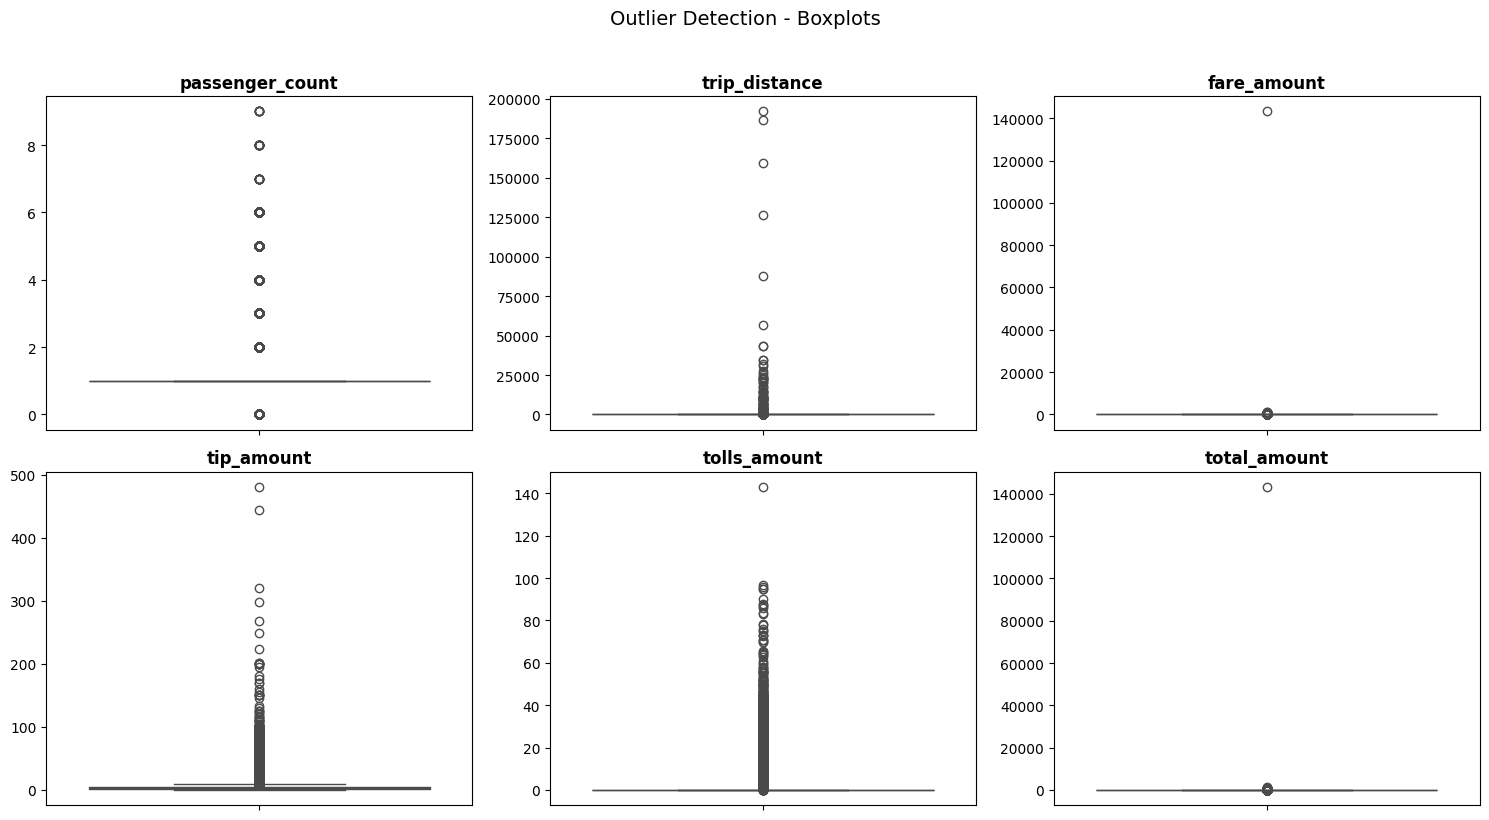

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_outliers(df, numeric_cols):
    # Create a grid of boxplots
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    for ax, col in zip(axes.flat, numeric_cols):
        sns.boxplot(y=df[col], ax=ax, color='steelblue')
        ax.set_title(f'{col}', fontsize=12, fontweight='bold')
        ax.set_ylabel('')

    plt.suptitle('Outlier Detection - Boxplots', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 
                'tip_amount', 'tolls_amount', 'total_amount']
plot_outliers(df, numeric_cols)

In [ ]:
weird_trip = df[df['fare_amount'] > 14000.00]
weird_trip

# Trip distance is 0, so this is likely an error in fare amount. 
# We can drop this row as it is just one row and will not affect our analysis much.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,congestion_surcharge,airport_fee
2532552,1,2023-09-05 10:16:13,2023-09-05 10:20:56,1.00,0.70,1.00,249,90,2,143163.45,0.00,0.00,143167.45,2.50,0.00


In [156]:
df = df[df['fare_amount'] < 14000]  

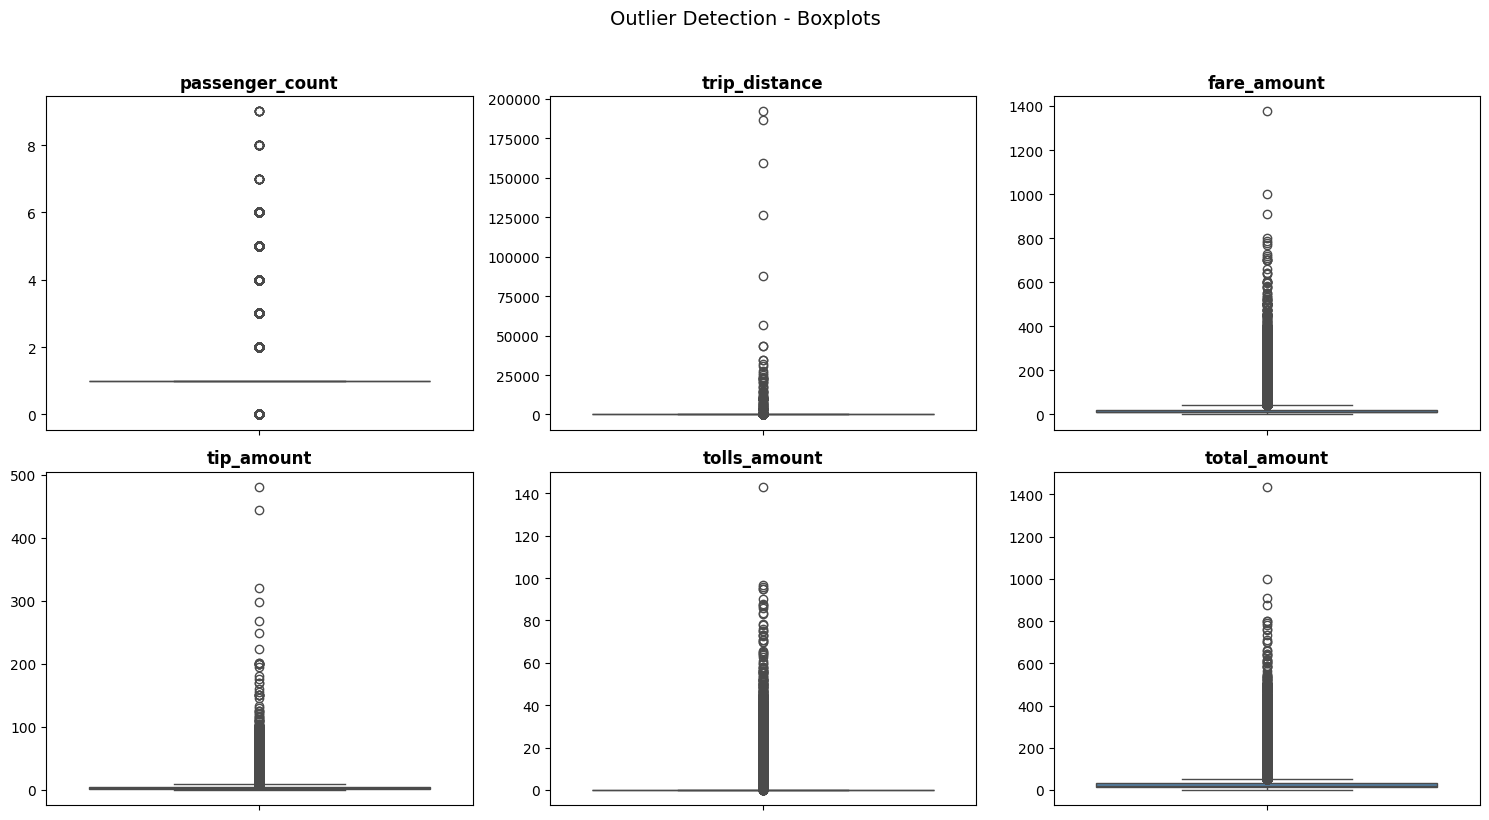

In [157]:
plot_outliers(df, numeric_cols)

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [158]:
initial_rows = len(df)
print(f"Starting rows: {initial_rows:,}")

Starting rows: 3,475,941


In [159]:
# remove passenger_count > 6
# 0 passengers or > 6
print(f"Passenger count 0: {(df['passenger_count'] == 0).sum()}")
print(f"Passenger count > 6: {(df['passenger_count'] > 6).sum()}")
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]

Passenger count 0: 55252
Passenger count > 6: 35


In [160]:
# Continue with outlier handling

# Trip distance near zero but fare > $300 - probably human error or data error
bad_fare_no_distance = df[(df['trip_distance'] < 0.1) & (df['fare_amount'] > 300)]
print(f"Trips with ~0 distance but fare > $300: {len(bad_fare_no_distance)}")

df = df[~((df['trip_distance'] < 0.1) & (df['fare_amount'] > 300))]

Trips with ~0 distance but fare > $300: 62


In [161]:
# Both zero, but different pickup/dropoff zones - impossible
impossible_trips = df[
    (df['trip_distance'] == 0) & 
    (df['fare_amount'] == 0) & 
    (df['PULocationID'] != df['DOLocationID'])
]
print(f"Zero distance/fare but different zones: {len(impossible_trips)}")


Zero distance/fare but different zones: 113


In [162]:
df = df[~(
    (df['trip_distance'] == 0) & 
    (df['fare_amount'] == 0) & 
    (df['PULocationID'] != df['DOLocationID'])
)]

In [163]:
# Trips > 250 miles
too_long = df[df['trip_distance'] > 250]
print(f"Trips > 250 miles: {len(too_long)}")

Trips > 250 miles: 87


In [164]:
df = df[df['trip_distance'] <= 250]

In [165]:
# Check what payment types exist
print(df['payment_type'].value_counts())

payment_type
1    2696759
2     570437
0     113801
4      24304
3      15091
Name: count, dtype: int64


In [166]:
# Drop payment_type 0
print(f"Trips with payment_type 0: {(df['payment_type'] == 0).sum()}")
df = df[df['payment_type'] != 0]

Trips with payment_type 0: 113801


In [167]:
# Check if there are any trips with negative duration - which is not possible
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
print(f"Negative duration: {(df['trip_duration_min'] <= 0).sum()}")

Negative duration: 1090


In [168]:
df = df[(df['trip_duration_min'] > 0)]

In [169]:
df = df.drop(columns=['trip_duration_min'])


In [170]:
final_rows = len(df)
print(f"Final rows after outlier removal: {final_rows:,}")
print(f"Total rows removed: {initial_rows - final_rows:,}")

Final rows after outlier removal: 3,305,501
Total rows removed: 170,440


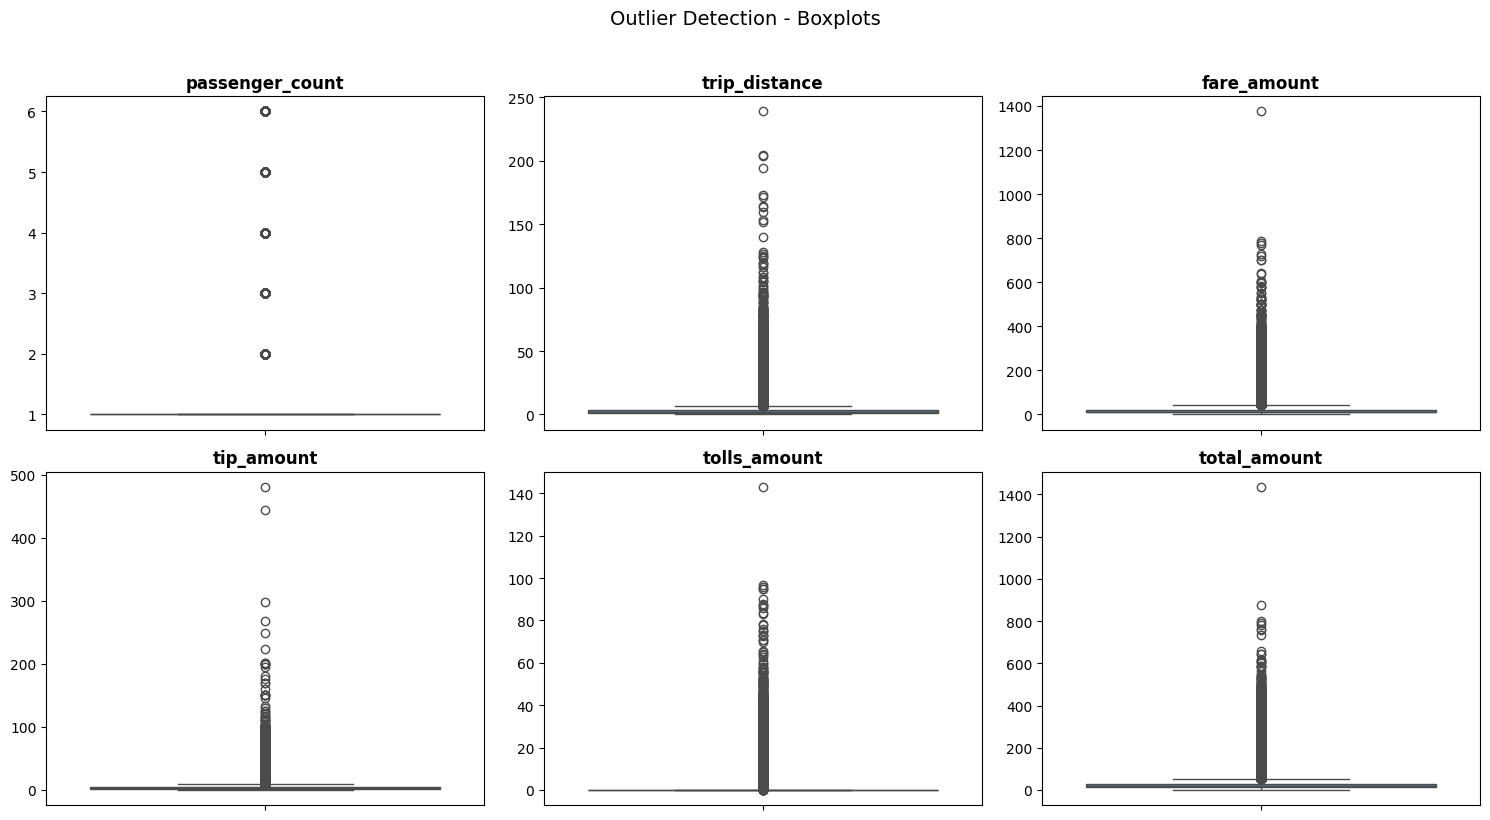

In [171]:
# Check the boxplots again after outlier handling
plot_outliers(df, numeric_cols)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [172]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'tip_amount',
 'tolls_amount',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

* `***** Answer *****`

* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical (datetime)
* `tpep_dropoff_datetime`: Numerical (datetime)
* `passenger_count`: Numerical
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Categorical
* `DOLocationID`: Categorical
* `payment_type`: Categorical
* `pickup_hour`: Categorical
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`: Numerical
* `extra` : Numerical
* `mta_tax` : Numerical
* `tip_amount` : Numerical
* `tolls_amount` : Numerical
* `improvement_surcharge` : Numerical
* `total_amount` : Numerical
* `congestion_surcharge` : Numerical
* `airport_fee` : Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [217]:
# Find and show the hourly trends in taxi pickups

# Extract time components from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()  # Monday, Tuesday, etc.
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()  # January, February, etc.

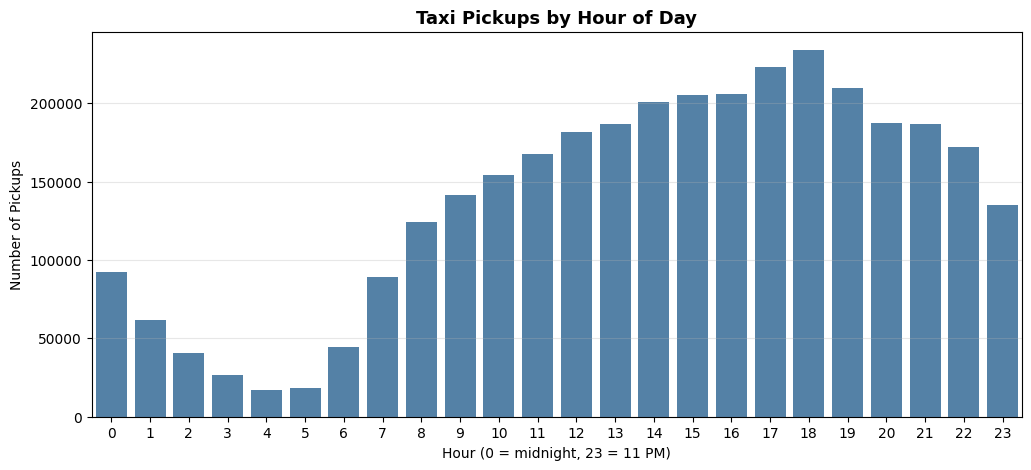

In [218]:
# Find and show the daily trends in taxi pickups (days of the week)
import matplotlib.pyplot as plt
import seaborn as sns

# Count pickups per hour
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, color='steelblue')
plt.title('Taxi Pickups by Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour (0 = midnight, 23 = 11 PM)')
plt.ylabel('Number of Pickups')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.show()


**Hourly pattern:**
- Pickups peak daily: morning rush starts around (7-9 AM) and peaks at 6 pm
- Lowest activity: 3-5 AM


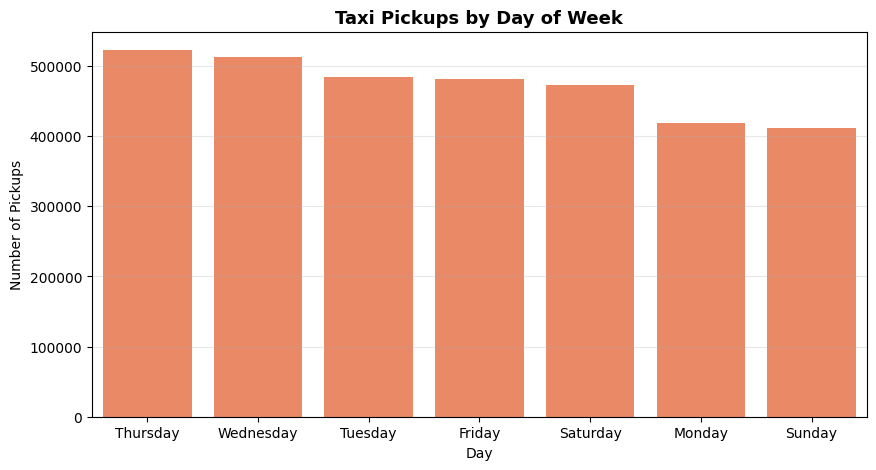

In [219]:
daily_pickups = df['pickup_day'].value_counts()

plt.figure(figsize=(10, 5))
sns.barplot(x=daily_pickups.index, y=daily_pickups.values, color='coral')
plt.title('Taxi Pickups by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Number of Pickups')
plt.grid(axis='y', alpha=0.3)
plt.show()


**Weekly pattern:**
- Wednesday and Thursday show the highest volume
- Monday and Sunday are lowest

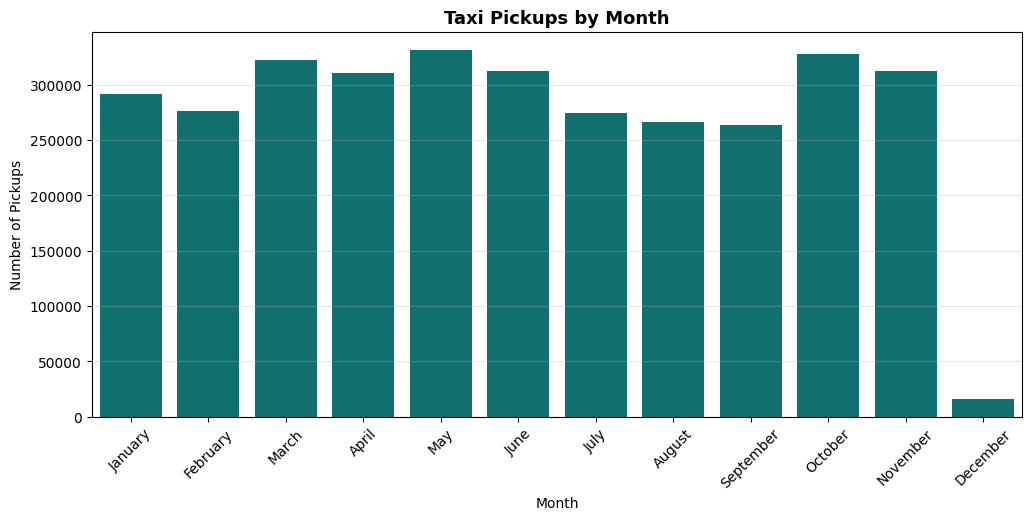

In [220]:
# Show the monthly trends in pickups
# Order months chronologically, otherwise they will be ordered alphabetically in the plot
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_pickups = df['pickup_month'].value_counts().reindex(month_order)

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_pickups.index, y=monthly_pickups.values, color='teal')
plt.title('Taxi Pickups by Month', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


**Monthly pattern:**
- Surprisingly very low volume in December (holiday season). Is this expected????
- September has lowest count (partly due to fewer days)
- Observing a cyclic pattern over months

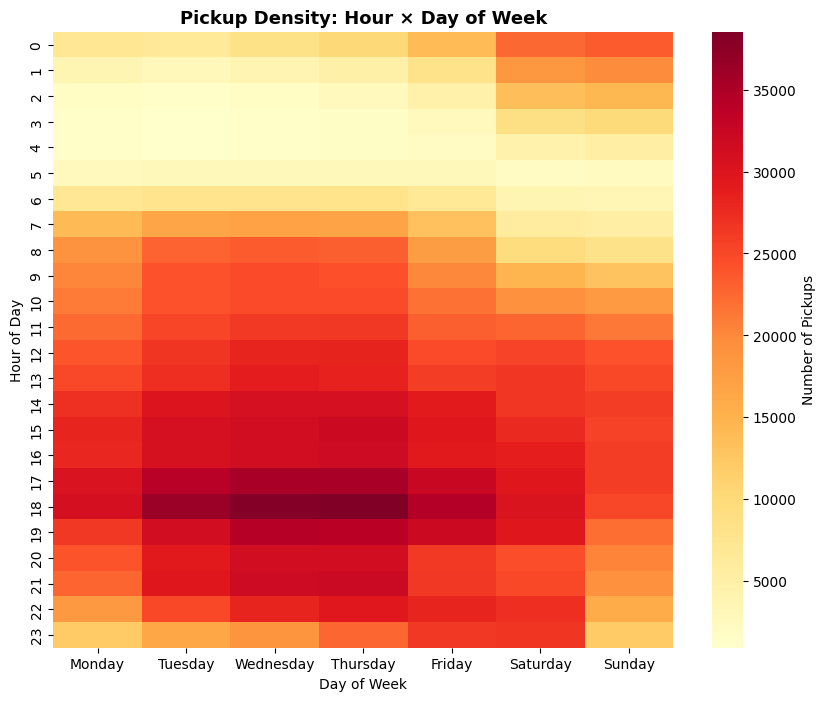

In [221]:
# Pivot table: rows = hours, cols = days, values = pickup count
hour_day = df.groupby(['pickup_hour', 'pickup_day']).size().unstack()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
             'Friday', 'Saturday', 'Sunday']
# Reorder columns to Mon-Sun
hour_day = hour_day[day_order]

plt.figure(figsize=(10, 8))
sns.heatmap(hour_day, cmap='YlOrRd', annot=False, fmt='d', 
            cbar_kws={'label': 'Number of Pickups'})
plt.title('Pickup Density: Hour × Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.show()

**Cross-pattern insight (from heatmap):**
- Weekday rush-hour bands are clearly visible
- Weekend pattern shifts later: minimal morning activity, but good late-night spikes on Fri/Sat
- Overall I see From Tuesday 7:30 to Thrsday 22:30 having good volume 

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [222]:
# Analyse the above parameters

cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    neg_count = (df[col] < 0).sum()
    total = len(df)
    
    print(f"\n--- {col} ---")
    print(f"Zero values:     {zero_count:,} ({zero_count/total*100:.2f}%)")
    print(f"Negative values: {neg_count:,} ({neg_count/total*100:.2f}%)")
    print(f"Min value:       {df[col].min()}")


--- fare_amount ---
Zero values:     836 (0.03%)
Negative values: 0 (0.00%)
Min value:       0.0

--- tip_amount ---
Zero values:     736,330 (22.28%)
Negative values: 0 (0.00%)
Min value:       0.0

--- total_amount ---
Zero values:     436 (0.01%)
Negative values: 0 (0.00%)
Min value:       0.0

--- trip_distance ---
Zero values:     39,097 (1.18%)
Negative values: 0 (0.00%)
Min value:       0.0


1. Its okay for fare_amount to have zeroes, it means the rides were cancelled.
2. Its okay for trip_amount to have zeroes as people usually dont tip.
3. total_amount can be zero as well, for cancelled trips. But this also means trips can have non zerp tip amount for zero fare amount.

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes, its better to remove them but it depends on the use-case. If we are building a trip prediction model then these can be removed. If its for data analysis and user behaviour understanding then its better if they are kept.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

Answer: When pickup and dropoff fall in the same taxi zone, a recorded distance of 0 can represent a legitimate short trip where the GPS distance was rounded to zero. As long as the fare_amount is positive, these represent real trips and should be retained.

In [223]:
# Create a df with non zero entries for the selected parameters.

# Drop trips with zero fare_amount (these are errors or cancelled trips)
df = df[df['fare_amount'] > 0]

# Drop trips with zero total_amount (cancelled/voided)
df = df[df['total_amount'] > 0]


In [224]:
# Analyse the parameters

cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols_to_check:
    zero_count = (df[col] == 0).sum()
    neg_count = (df[col] < 0).sum()
    total = len(df)
    
    print(f"\n--- {col} ---")
    print(f"Zero values:     {zero_count:,} ({zero_count/total*100:.2f}%)")
    print(f"Negative values: {neg_count:,} ({neg_count/total*100:.2f}%)")
    print(f"Min value:       {df[col].min()}")


--- fare_amount ---
Zero values:     0 (0.00%)
Negative values: 0 (0.00%)
Min value:       0.01

--- tip_amount ---
Zero values:     735,518 (22.26%)
Negative values: 0 (0.00%)
Min value:       0.0

--- total_amount ---
Zero values:     0 (0.00%)
Negative values: 0 (0.00%)
Min value:       1.01

--- trip_distance ---
Zero values:     38,698 (1.17%)
Negative values: 0 (0.00%)
Min value:       0.0


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [228]:
# Group data by month and analyse monthly revenue

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
df['pickup_month_name'] = df['tpep_pickup_datetime'].dt.month_name()

# Group by month and compute revenue metrics
monthly_revenue = df.groupby('pickup_month').agg(
    total_amount=('total_amount', 'sum'),
    trip_count=('total_amount', 'count'),
    avg_fare_per_trip=('total_amount', 'mean'),
    median_fare=('total_amount', 'median')
).round(2)

# Add month name for readability
month_names = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_revenue.index = [month_names[i-1] for i in monthly_revenue.index]

print(monthly_revenue)

           total_amount  trip_count  avg_fare_per_trip  median_fare
January      7981068.49      291571              27.37        20.15
February     7548990.26      276286              27.32        20.16
March        9109916.66      322385              28.26        20.62
April        8939237.30      310903              28.75        20.93
May          9746795.06      331477              29.40        21.36
June         9176821.58      312098              29.40        21.30
July         7984508.69      274474              29.09        21.00
August       7771538.40      265957              29.22        21.00
September    7951489.24      263445              30.18        21.80
October      9771195.35      328178              29.77        21.72
November     9141842.31      312333              29.27        21.48
December      456726.46       15558              29.36        21.36


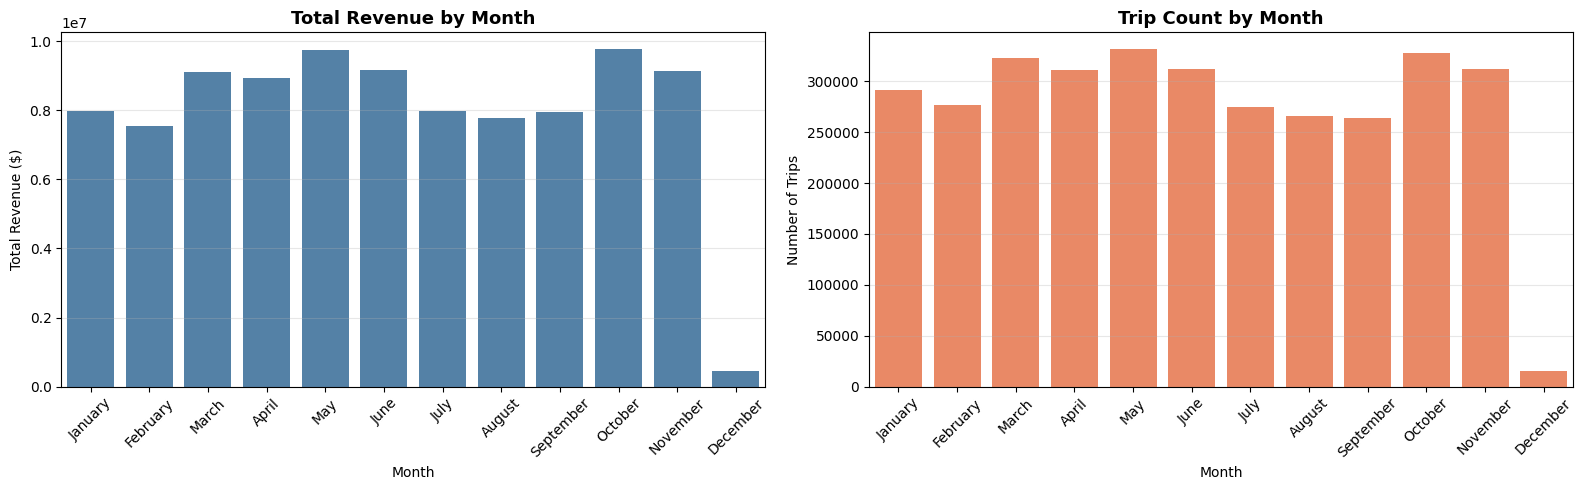

In [227]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total revenue per month
sns.barplot(x=monthly_revenue.index, y=monthly_revenue['total_revenue'], 
            ax=axes[0], color='steelblue')
axes[0].set_title('Total Revenue by Month', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Trip count per month
sns.barplot(x=monthly_revenue.index, y=monthly_revenue['trip_count'], 
            ax=axes[1], color='coral')
axes[1].set_title('Trip Count by Month', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Trips')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [193]:
# Calculate proportion of each quarter



In [231]:
# Show how trip fare is affected by distance

df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.quarter

# Group by quarter and compute totals
quarterly = df.groupby('pickup_quarter').agg(
    total_revenue=('total_amount', 'sum'),
    trip_count=('total_amount', 'count')
)

# Calculate proportions
quarterly['revenue_proportion'] = (quarterly['total_revenue'] / quarterly['total_revenue'].sum() * 100).round(2)
quarterly['trip_proportion'] = (quarterly['trip_count'] / quarterly['trip_count'].sum() * 100).round(2)

# Rename index for clarity
quarterly.index = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']

print(quarterly)

              total_revenue  trip_count  revenue_proportion  trip_proportion
Q1 (Jan-Mar)    24639975.41      890242               25.78            26.94
Q2 (Apr-Jun)    27862853.94      954478               29.15            28.88
Q3 (Jul-Sep)    23707536.33      803876               24.80            24.33
Q4 (Oct-Dec)    19369764.12      656069               20.27            19.85


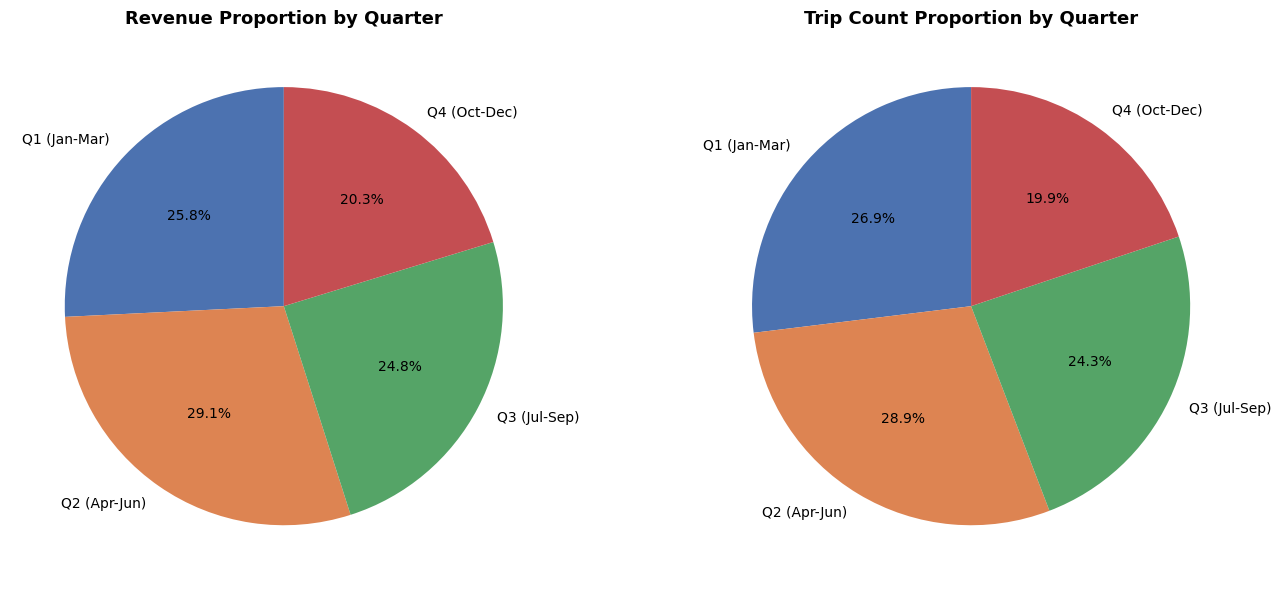

In [ ]:

# Visualize the revenue and trip count by qurter using pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue proportion
axes[0].pie(quarterly['revenue_proportion'], 
            labels=quarterly.index,
            autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A467', '#C44E52'],
            startangle=90)
axes[0].set_title('Revenue Proportion by Quarter', fontsize=13, fontweight='bold')

# Trip count proportion
axes[1].pie(quarterly['trip_proportion'], 
            labels=quarterly.index,
            autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452', '#55A467', '#C44E52'],
            startangle=90)
axes[1].set_title('Trip Count Proportion by Quarter', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Insight: Revenue is ~proportional to the trips made
Q2 has the most revenue and trip count, while Q4 has least

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

fare_amount vs trip_duration_min: 0.2637
fare_amount vs passenger_count: 0.0440
tip_amount vs trip_distance: 0.5742


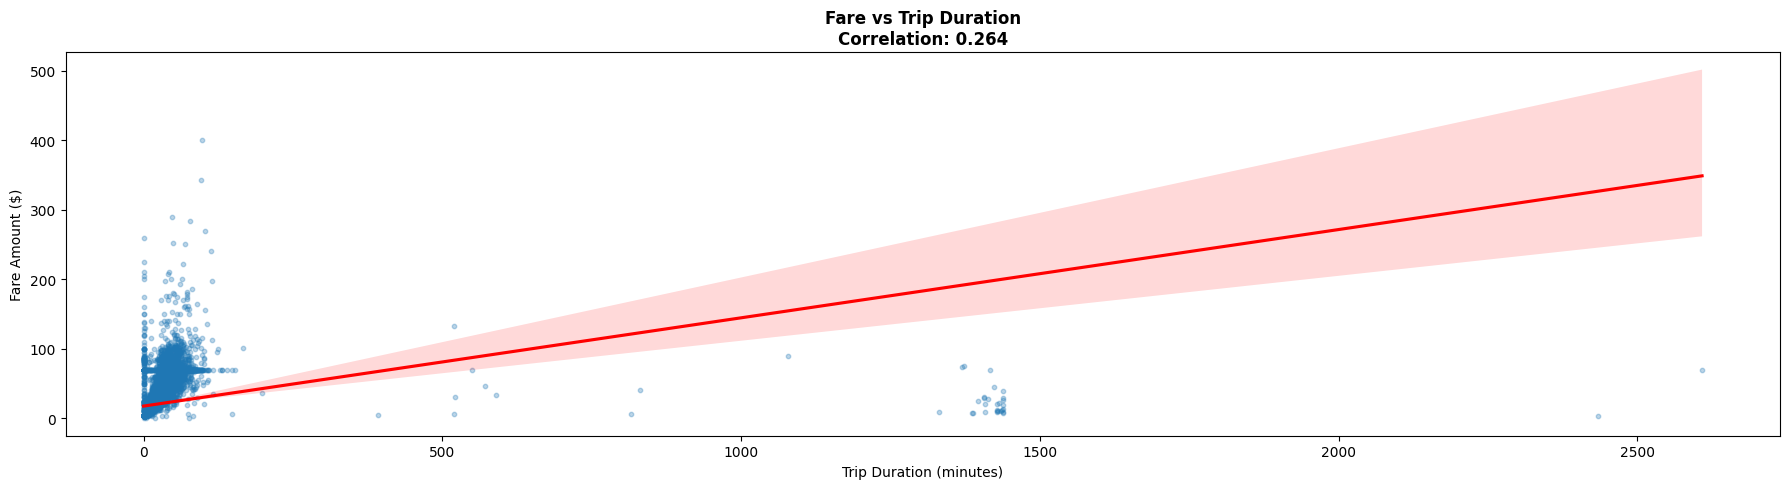

In [237]:
# Show relationship between fare and trip duration

# Trip duration in minutes
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

correlations = {
    'fare_amount vs trip_duration_min': df['fare_amount'].corr(df['trip_duration_min']),
    'fare_amount vs passenger_count':   df['fare_amount'].corr(df['passenger_count']),
    'tip_amount vs trip_distance':      df['tip_amount'].corr(df['trip_distance'])
}

for pair, corr in correlations.items():
    print(f"{pair}: {corr:.4f}")

# Sample for plotting (full dataset is too dense to render)
sample = df.sample(50000, random_state=42)

fig, axes = plt.subplots(1, 1, figsize=(18, 5))

# 1. fare vs trip duration
sns.regplot(data=sample, x='trip_duration_min', y='fare_amount', 
            ax=axes, scatter_kws={'alpha': 0.3, 's': 10}, 
            line_kws={'color': 'red'})
axes.set_title(f'Fare vs Trip Duration\nCorrelation: {correlations["fare_amount vs trip_duration_min"]:.3f}',
                  fontsize=12, fontweight='bold')
axes.set_xlabel('Trip Duration (minutes)')
axes.set_ylabel('Fare Amount ($)')


plt.tight_layout()
plt.show()

Text(0, 0.5, 'Fare Amount ($)')

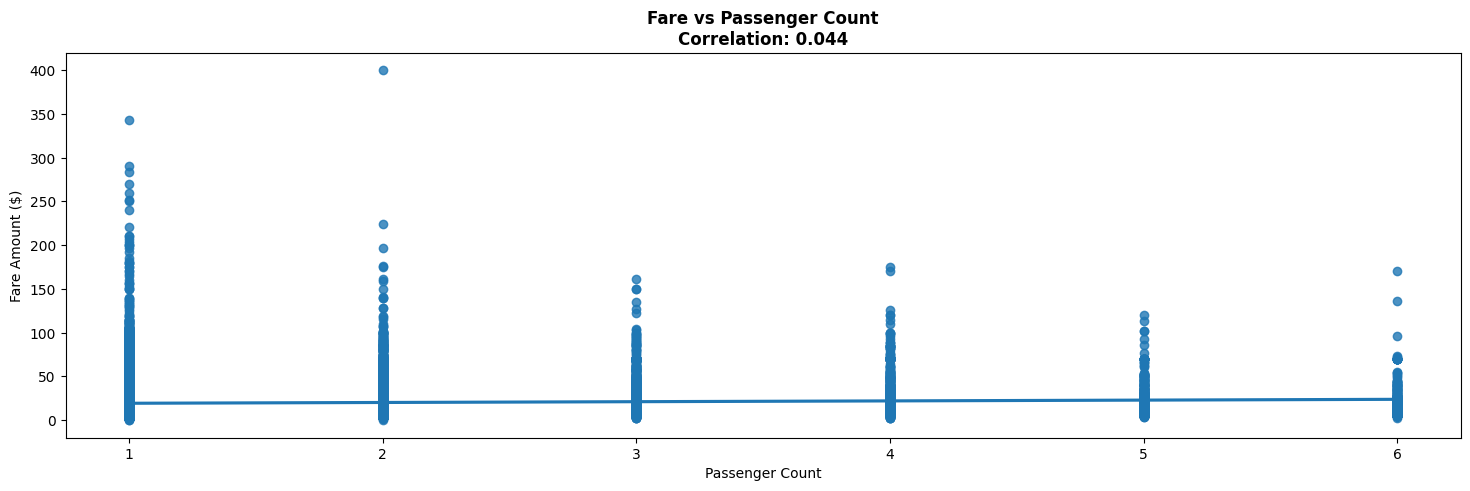

In [238]:
# Show relationship between fare and number of passengers

fig, axes = plt.subplots(1, 1, figsize=(18, 5))

# 2. fare vs passenger count
sns.regplot(data=sample, x='passenger_count', y='fare_amount')

axes.set_title(f'Fare vs Passenger Count\nCorrelation: {correlations["fare_amount vs passenger_count"]:.3f}',
                  fontsize=12, fontweight='bold')
axes.set_xlabel('Passenger Count')
axes.set_ylabel('Fare Amount ($)')


Text(0, 0.5, 'Tip Amount ($)')

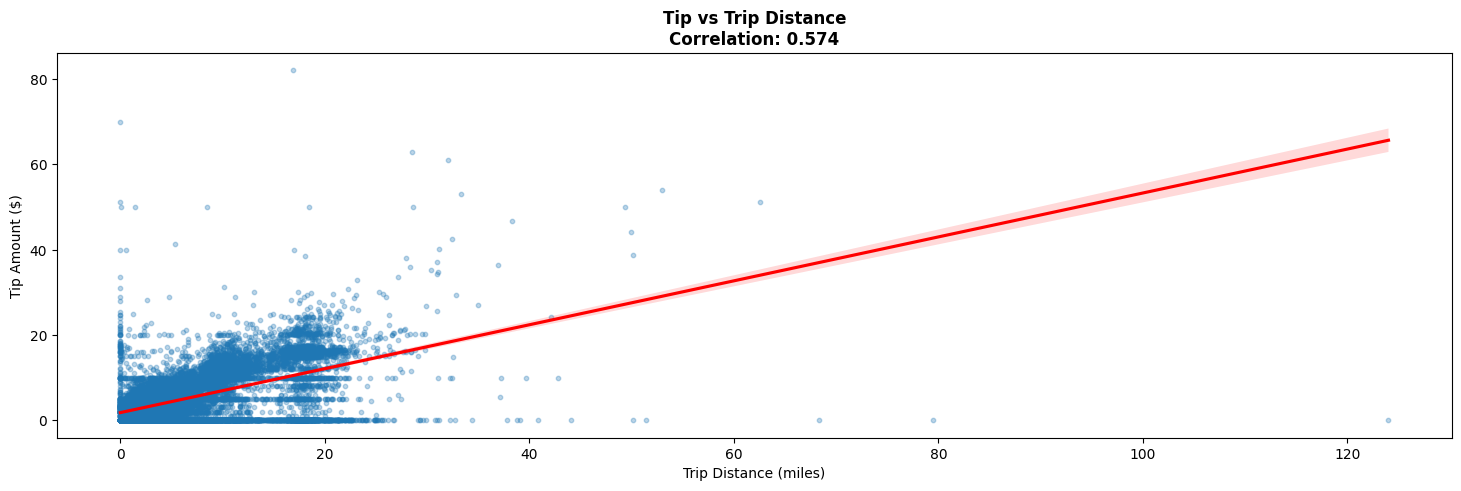

In [239]:
# Show relationship between tip and trip distance
# 3. tip vs trip distance
fig, axes = plt.subplots(1, 1, figsize=(18, 5))

sns.regplot(data=sample, x='trip_distance', y='tip_amount', 
            scatter_kws={'alpha': 0.3, 's': 10}, 
            line_kws={'color': 'red'})
axes.set_title(f'Tip vs Trip Distance\nCorrelation: {correlations["tip_amount vs trip_distance"]:.3f}',
                  fontsize=12, fontweight='bold')
axes.set_xlabel('Trip Distance (miles)')
axes.set_ylabel('Tip Amount ($)')



Insights: 
1. trip_amount is highly correlated with trip_distance which makes sense.
2. Trips with lower passenger count tend to have higher fares than trips with higher passenger counts.
3. Fare vs trip_duration is positively correlated but looks like a few outliers are highly distorting the data.

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

              trip_count  percentage
payment_type                        
1                2696360       81.59
2                 569277       17.23
3                  14901        0.45
4                  24127        0.73


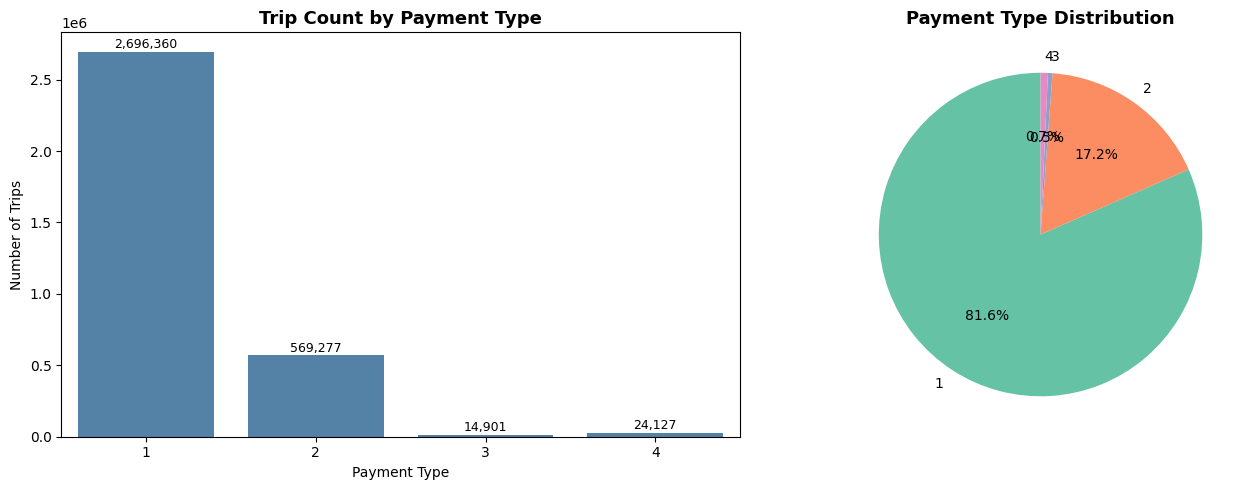

In [240]:
# Analyse the distribution of different payment types (payment_type).

# Counts and percentages
payment_counts = df['payment_type'].value_counts().sort_index()
payment_pct = df['payment_type'].value_counts(normalize=True).sort_index() * 100

# Combine into one readable table
payment_summary = pd.DataFrame({
    'trip_count': payment_counts,
    'percentage': payment_pct.round(2)
})

print(payment_summary)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart - precise counts
sns.barplot(x=payment_counts.index, y=payment_counts.values, 
            ax=axes[0], color='steelblue')
axes[0].set_title('Trip Count by Payment Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Number of Trips')

# Add count labels on bars
for i, v in enumerate(payment_counts.values):
    axes[0].text(i, v + max(payment_counts.values) * 0.01, 
                 f'{v:,}', ha='center', fontsize=9)

# Pie chart - proportions  
axes[1].pie(payment_counts.values, labels=payment_counts.index, 
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('Set2', len(payment_counts)))
axes[1].set_title('Payment Type Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



Insight: 
1. Payment method 1 (Credit Card) (81 %) is most popular followed by cash.

##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [199]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [ ]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('./taxi_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.12,0.00,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.43,0.00,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.08,0.00,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.04,0.00,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.09,0.00,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    str     
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    str     
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 18.5 KB
None


<Axes: >

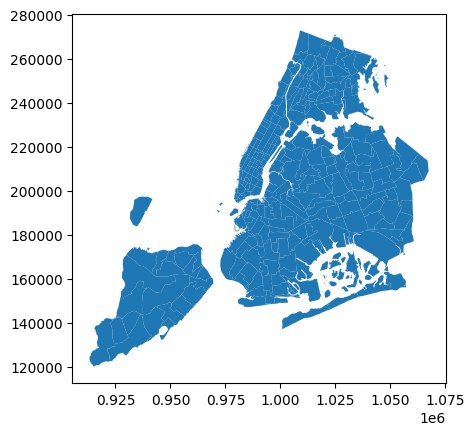

In [252]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [254]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'tip_amount',
 'tolls_amount',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_name',
 'pickup_quarter',
 'trip_duration_min']

In [255]:
# Merge zones and trip records using locationID and PULocationID
df_merged = df.merge(
    zones[['LocationID', 'zone', 'borough', 'geometry']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)


In [256]:
df_merged.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,...,pickup_hour,pickup_day,pickup_month,pickup_month_name,pickup_quarter,trip_duration_min,LocationID,zone,borough,geometry
0,2,2022-12-31 23:51:30,2022-12-31 23:56:06,1.00,0.86,1.00,141,140,1,6.50,...,23,Saturday,12,December,4,4.60,141.00,Lenox Hill West,Manhattan,"POLYGON ((994839.073 216123.698, 994786.74 216..."
1,2,2022-12-31 23:58:08,2023-01-01 00:08:28,1.00,2.83,1.00,163,75,1,14.20,...,23,Saturday,12,December,4,10.33,163.00,Midtown North,Manhattan,"POLYGON ((989412.663 219020.943, 990045.841 21..."
2,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.00,7.74,1.00,138,256,2,32.40,...,0,Sunday,1,January,1,15.95,138.00,LaGuardia Airport,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
3,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.00,1.24,1.00,161,237,1,7.90,...,0,Sunday,1,January,1,5.08,161.00,Midtown Center,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
4,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.00,1.44,1.00,237,141,2,11.40,...,0,Sunday,1,January,1,10.55,237.00,Upper East Side South,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."


In [257]:
df_merged.columns.tolist()


['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'tip_amount',
 'tolls_amount',
 'total_amount',
 'congestion_surcharge',
 'airport_fee',
 'pickup_hour',
 'pickup_day',
 'pickup_month',
 'pickup_month_name',
 'pickup_quarter',
 'trip_duration_min',
 'LocationID',
 'zone',
 'borough',
 'geometry']

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [260]:
# Group by LocationID and count trips
trips_by_location = df_merged.groupby('LocationID').size().reset_index(name='trip_count')

# Sort by busiest
trips_by_location = trips_by_location.sort_values('trip_count', ascending=False)

print(f"Total unique locations: {len(trips_by_location)}")
print("\nTop 10 busiest pickup locations:")
print(trips_by_location.head(10))

Total unique locations: 255

Top 10 busiest pickup locations:
     LocationID  trip_count
125      132.00      178147
229      237.00      156436
154      161.00      154859
228      236.00      138886
155      162.00      118604
131      138.00      117288
178      186.00      114367
222      230.00      110686
135      142.00      108376
163      170.00       98956


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [263]:
# Merge trip counts back to the zones GeoDataFrame

# Merge trip counts INTO the zones GeoDataFrame
zones_with_trips = zones.merge(
    trips_by_location[['LocationID', 'trip_count']],
    on='LocationID',
    how='left'
)

# Fill NaN trip counts with 0 (zones that had no pickups)
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)

print(zones_with_trips.head())

   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1        0.12        0.00           Newark Airport           1   
1         2        0.43        0.00              Jamaica Bay           2   
2         3        0.08        0.00  Allerton/Pelham Gardens           3   
3         4        0.04        0.00            Alphabet City           4   
4         5        0.09        0.00            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  Staten Island  POLYGON ((935843.31 144283.336, 936046.565 144...   

   trip_count  
0      401.00  
1        2.00  
2       68.00  
3     3328.00  
4       32.00  


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

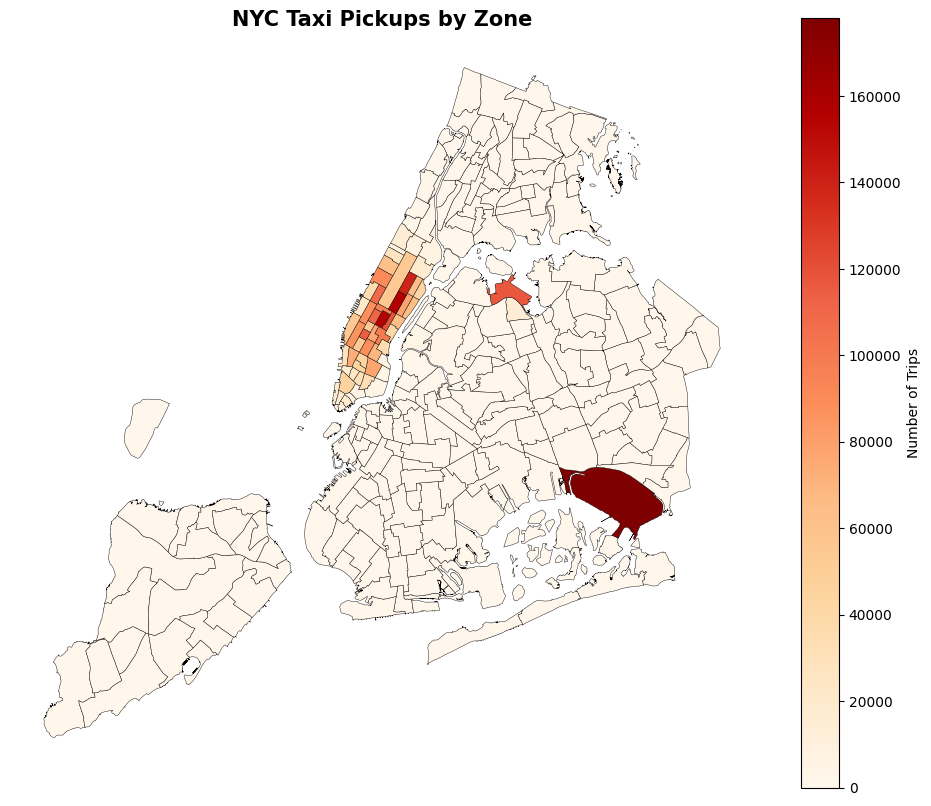

In [265]:
# Define figure and axis
# Plot the map and display it
import matplotlib.pyplot as plt

# Step 1: Set up the figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Step 2: Plot the GeoDataFrame, color-coded by trip_count
zones_with_trips.plot(
    column='trip_count',                  # the value that determines each zone's color
    ax=ax,                                 # plot onto our axis
    legend=True,                           # show the color scale legend
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'vertical'
    },
    cmap='OrRd',                           # colormap: light = few trips, dark = many trips
    edgecolor='black',                     # zone borders
    linewidth=0.3                          # thin borders
)

# Step 3: Style the plot
ax.set_title('NYC Taxi Pickups by Zone', fontsize=15, fontweight='bold')
ax.set_axis_off()  # hide the lat/lon axis ticks (cleaner look for maps)

plt.show()


In [266]:
# can you try displaying the zones DF sorted by the number of trips?

# Sort zones by trip count, descending (busiest first)
sorted_zones = zones_with_trips.sort_values('trip_count', ascending=False)

# Display key columns
sorted_zones[['LocationID', 'zone', 'borough', 'trip_count']].head(20)

,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,178147.00
236,237,Upper East Side South,Manhattan,156436.00
160,161,Midtown Center,Manhattan,154859.00
235,236,Upper East Side North,Manhattan,138886.00
161,162,Midtown East,Manhattan,118604.00
137,138,LaGuardia Airport,Queens,117288.00
185,186,Penn Station/Madison Sq West,Manhattan,114367.00
229,230,Times Sq/Theatre District,Manhattan,110686.00
141,142,Lincoln Square East,Manhattan,108376.00
169,170,Murray Hill,Manhattan,98956.00


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


# Add Insights here:

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [268]:
# Find routes which have the slowest speeds at different times of the day

# Speed in kmph per hour
df_merged['speed_kmph'] = df_merged['trip_distance'] / (df_merged['trip_duration_min'] / 60)

# Quick sanity check
print(df_merged['speed_kmph'].describe())

count   3304897.00
mean         11.95
std          74.22
min           0.00
25%           7.15
50%           9.66
75%          13.39
max       42264.00
Name: speed_kmph, dtype: float64


In [270]:
def categorize_time(hour):
    if 6 <= hour < 10:
        return '1. Morning Rush (6-10 AM)'
    elif 10 <= hour < 16:
        return '2. Midday (10 AM-4 PM)'
    elif 16 <= hour < 20:
        return '3. Evening Rush (4-8 PM)'
    elif 20 <= hour < 24:
        return '4. Night (8 PM-12 AM)'
    else:
        return '5. Late Night (12-6 AM)'

df_merged['time_period'] = df_merged['pickup_hour'].apply(categorize_time)

# Let's add dropoff zone info via merge:
df_merged = df_merged.merge(
    zones[['LocationID', 'zone', 'borough']].rename(
        columns={'LocationID': 'do_loc', 'zone': 'do_zone', 'borough': 'do_borough'}
    ),
    left_on='DOLocationID',
    right_on='do_loc',
    how='left'
).drop(columns=['do_loc'])

# Rename pickup zone for clarity (it was just 'zone' before)
df_merged = df_merged.rename(columns={
    'zone': 'pu_zone',
    'borough': 'pu_borough'
})

# Now create the route identifier
df_merged['route'] = df_merged['pu_zone'] + ' → ' + df_merged['do_zone']

In [271]:
# Group by route AND time period, calculate average speed
route_speeds = df_merged.groupby(['time_period', 'route']).agg(
    avg_speed=('speed_mph', 'mean'),
    trip_count=('speed_mph', 'count'),
    avg_distance=('trip_distance', 'mean')
).round(2).reset_index()

# IMPORTANT: filter for routes with enough data to be reliable
# Single trips with low speed could be flukes - need a minimum sample size
route_speeds = route_speeds[route_speeds['trip_count'] >= 50]

# Sort by speed - slowest first
route_speeds = route_speeds.sort_values(['time_period', 'avg_speed'])

# Show top 5 slowest routes per period
slowest_per_period = route_speeds.groupby('time_period').head(5)
print(slowest_per_period.to_string())

                     time_period                                                                route  avg_speed  trip_count  avg_distance
8496   1. Morning Rush (6-10 AM)  Saint Michaels Cemetery/Woodside → Saint Michaels Cemetery/Woodside       0.17         107          0.00
8182   1. Morning Rush (6-10 AM)                    Queensbridge/Ravenswood → Queensbridge/Ravenswood       1.00         219          0.03
9497   1. Morning Rush (6-10 AM)                Times Sq/Theatre District → Times Sq/Theatre District       5.64         292          0.74
3909   1. Morning Rush (6-10 AM)                                  Garment District → Garment District       5.68         150          0.62
1819   1. Morning Rush (6-10 AM)                                       Cobble Hill → Brooklyn Heights       6.19          50          0.57
22873     2. Midday (10 AM-4 PM)  Saint Michaels Cemetery/Woodside → Saint Michaels Cemetery/Woodside       0.02         207          0.00
21405     2. Midday (10 AM-

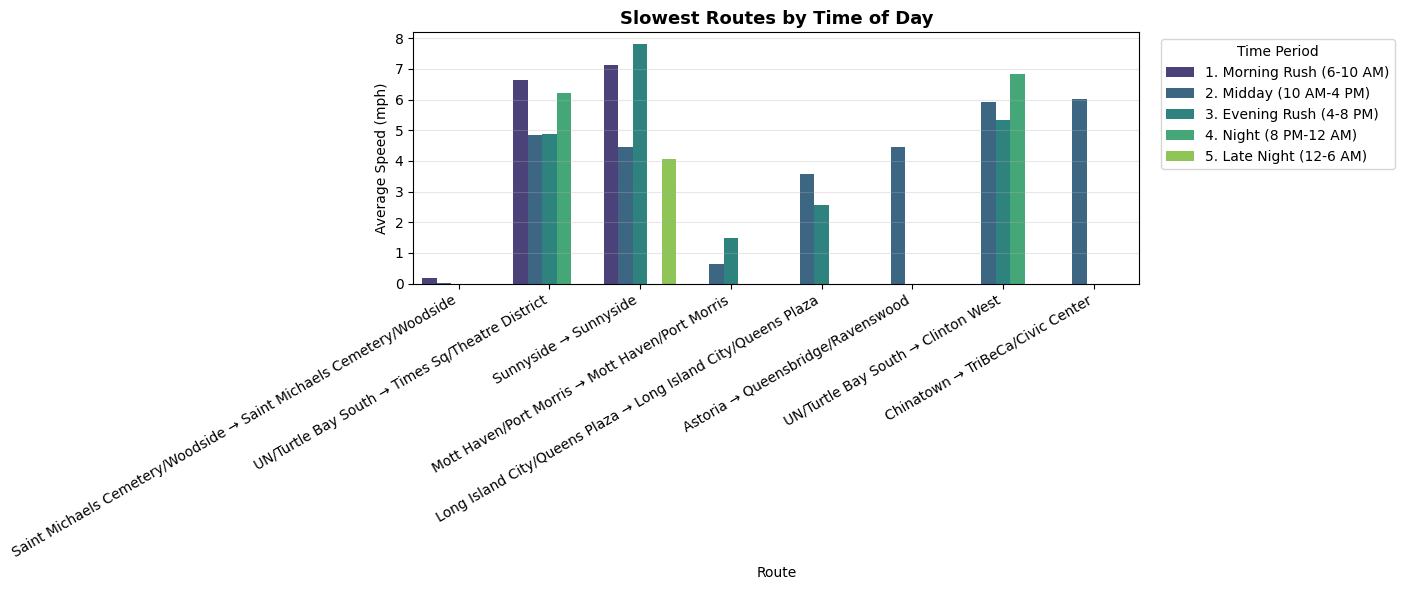

In [272]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get top 5 slowest routes overall (across all periods) - they're usually the same suspects
top_slow_routes = (route_speeds.groupby('route')['avg_speed']
                   .mean().nsmallest(8).index.tolist())

# Filter to just those routes
plot_data = route_speeds[route_speeds['route'].isin(top_slow_routes)]

plt.figure(figsize=(14, 6))
sns.barplot(data=plot_data, x='route', y='avg_speed', hue='time_period', palette='viridis')
plt.title('Slowest Routes by Time of Day', fontsize=13, fontweight='bold')
plt.xlabel('Route')
plt.ylabel('Average Speed (mph)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Time Period', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

How does identifying high-traffic, high-demand routes help us?

Answer:
Saves time: Drivers can save time if they are in high demand area they will get quick rides.
More revenue: Since its high demand area, drivers can get more revenue. 

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [273]:
# Group by hour and count
trips_per_hour = df_merged.groupby('pickup_hour').size().reset_index(name='trip_count')

print(trips_per_hour)


    pickup_hour  trip_count
0             0       92130
1             1       61737
2             2       40634
3             3       26519
4             4       17031
5             5       18223
6             6       44687
7             7       89095
8             8      124062
9             9      141486
10           10      154201
11           11      167422
12           12      181464
13           13      186983
14           14      200517
15           15      205269
16           16      205729
17           17      223349
18           18      233977
19           19      209717
20           20      187127
21           21      186864
22           22      172326
23           23      135279


In [274]:
# Visualise the number of trips per hour and find the busiest hour

# Find the row with the maximum trip count
busiest_hour_row = trips_per_hour.loc[trips_per_hour['trip_count'].idxmax()]

busiest_hour = busiest_hour_row['pickup_hour']
busiest_count = busiest_hour_row['trip_count']

print(f"Busiest hour: {busiest_hour}:00 ({busiest_hour}:00 - {busiest_hour}:59)")
print(f"Number of trips: {busiest_count:,}")

Busiest hour: 18:00 (18:00 - 18:59)
Number of trips: 233,977


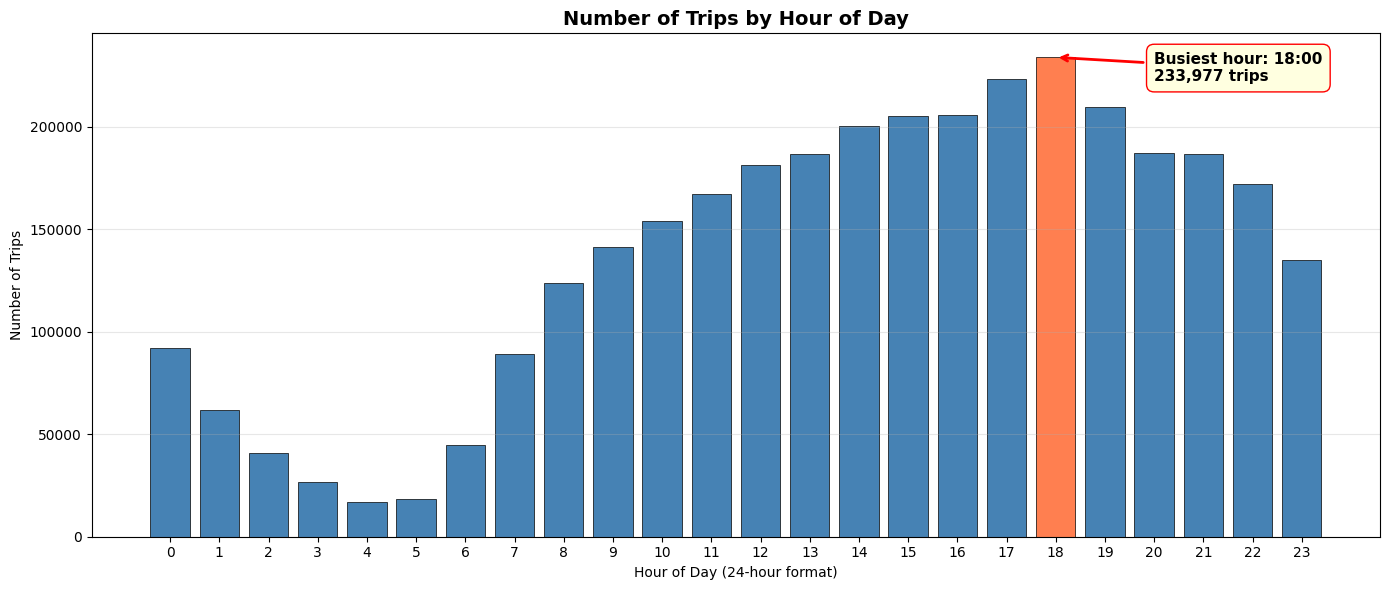

In [275]:
plt.figure(figsize=(14, 6))

# Color the busiest hour differently to make it stand out
colors = ['coral' if h == busiest_hour else 'steelblue' 
          for h in trips_per_hour['pickup_hour']]

bars = plt.bar(trips_per_hour['pickup_hour'], 
               trips_per_hour['trip_count'], 
               color=colors, edgecolor='black', linewidth=0.5)

# Annotate the busiest hour
plt.annotate(f'Busiest hour: {busiest_hour}:00\n{busiest_count:,} trips',
             xy=(busiest_hour, busiest_count),
             xytext=(busiest_hour + 2, busiest_count * 0.95),
             fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', edgecolor='red'))

plt.title('Number of Trips by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24-hour format)')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [ ]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction =



**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [276]:
# Compare traffic trends for the week days and weekends

# Get day of week (0 = Monday, 6 = Sunday)
df_merged['day_of_week'] = df_merged['tpep_pickup_datetime'].dt.dayofweek

# Categorise as weekday or weekend
df_merged['day_type'] = df_merged['day_of_week'].apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

# Verify
print(df_merged['day_type'].value_counts())

day_type
Weekday    2420598
Weekend     885230
Name: count, dtype: int64


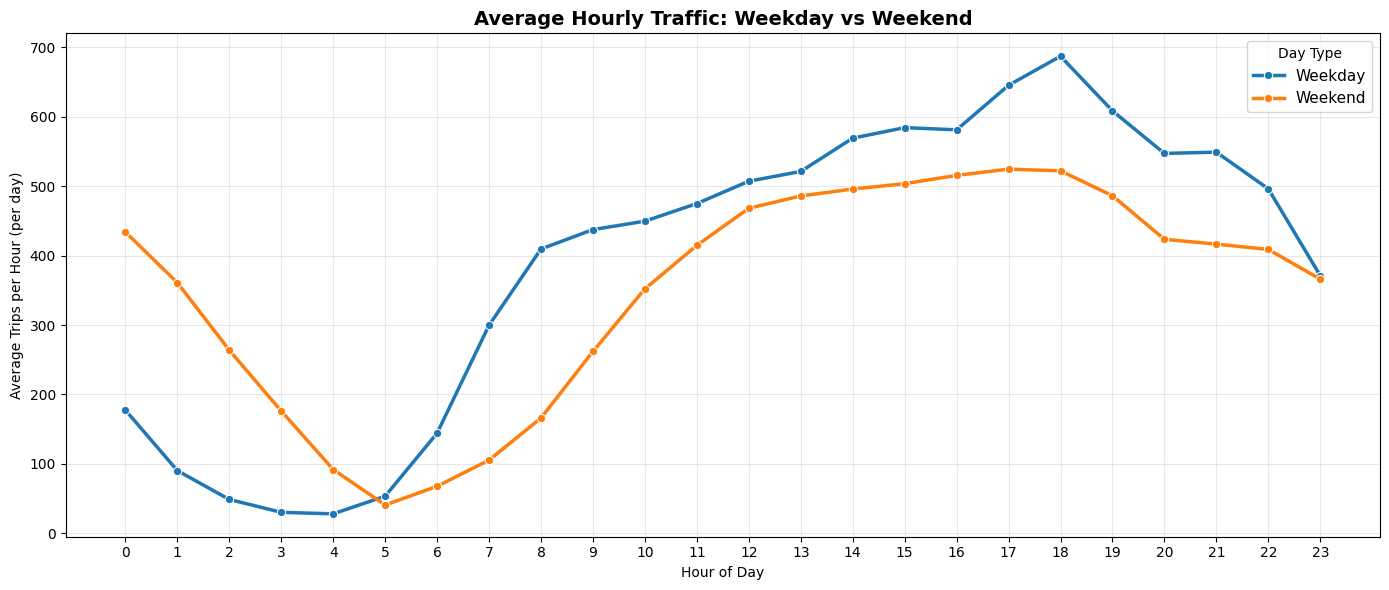

In [277]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average trips per hour per day for each category
hourly_pattern = df_merged.groupby(['day_type', 'pickup_hour']).size().reset_index(name='trips')

# Normalise by number of weekday/weekend days so the comparison is fair
days_count = df_merged.groupby('day_type')['tpep_pickup_datetime'].apply(
    lambda x: x.dt.date.nunique()
).to_dict()

hourly_pattern['avg_trips_per_day'] = hourly_pattern.apply(
    lambda row: row['trips'] / days_count[row['day_type']], axis=1
)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=hourly_pattern, x='pickup_hour', y='avg_trips_per_day', 
             hue='day_type', marker='o', linewidth=2.5)
plt.title('Average Hourly Traffic: Weekday vs Weekend', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips per Hour (per day)')
plt.xticks(range(24))
plt.legend(title='Day Type', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Both weekdays adn weekends follow similar trends.
The lowest demand for both is at 5 am while peak demand is 6 PM.

Fleet operators (Ola/Uber/Rapido) can align driver supply with hourly demand — concentrating more drivers during peak hours.
They can also have dynamic pricing.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [278]:
# Find top 10 pickup and dropoff zones

# Top 10 pickup zones (by total trips)
top_pickup_zones = (df_merged.groupby('LocationID')
                    .size()
                    .nlargest(10)
                    .index.tolist())

# Top 10 dropoff zones (by total trips)
top_dropoff_zones = (df_merged.groupby('DOLocationID')
                     .size()
                     .nlargest(10)
                     .index.tolist())

print("Top 10 Pickup LocationIDs:", top_pickup_zones)
print("Top 10 Dropoff LocationIDs:", top_dropoff_zones)

Top 10 Pickup LocationIDs: [132.0, 237.0, 161.0, 236.0, 162.0, 138.0, 186.0, 230.0, 142.0, 170.0]
Top 10 Dropoff LocationIDs: [236, 237, 161, 230, 170, 162, 142, 239, 141, 68]


These are only IDs, mapping Location ID to name for better visualization

In [279]:
# Map LocationID → zone name from your zones dataframe
zone_name_map = dict(zip(zones['LocationID'], zones['zone']))

print("\nTop 10 Pickup Zones:")
for loc_id in top_pickup_zones:
    print(f"  {loc_id}: {zone_name_map.get(loc_id, 'Unknown')}")

print("\nTop 10 Dropoff Zones:")
for loc_id in top_dropoff_zones:
    print(f"  {loc_id}: {zone_name_map.get(loc_id, 'Unknown')}")


Top 10 Pickup Zones:
  132.0: JFK Airport
  237.0: Upper East Side South
  161.0: Midtown Center
  236.0: Upper East Side North
  162.0: Midtown East
  138.0: LaGuardia Airport
  186.0: Penn Station/Madison Sq West
  230.0: Times Sq/Theatre District
  142.0: Lincoln Square East
  170.0: Murray Hill

Top 10 Dropoff Zones:
  236: Upper East Side North
  237: Upper East Side South
  161: Midtown Center
  230: Times Sq/Theatre District
  170: Murray Hill
  162: Midtown East
  142: Lincoln Square East
  239: Upper West Side South
  141: Lenox Hill West
  68: East Chelsea


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [280]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_data = df_merged[
    (df_merged['pickup_hour'] >= 23) | 
    (df_merged['pickup_hour'] <= 4)
]

print(f"Total night-hour trips: {len(night_data):,}")
print(f"% of all trips: {len(night_data) / len(df_merged) * 100:.2f}%")


Total night-hour trips: 373,330
% of all trips: 11.29%


In [281]:
# Top 10 night pickup zones
night_pickups = (night_data.groupby('LocationID')
                 .size()
                 .reset_index(name='night_pickups')
                 .sort_values('night_pickups', ascending=False))

# Add zone names
night_pickups = night_pickups.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

top_10_night_pu = night_pickups.head(10)
print("Top 10 NIGHT pickup zones (11 PM - 5 AM):")
print(top_10_night_pu[['LocationID', 'zone', 'borough', 'night_pickups']].to_string(index=False))

Top 10 NIGHT pickup zones (11 PM - 5 AM):
 LocationID                         zone   borough  night_pickups
      79.00                 East Village Manhattan          27726
     132.00                  JFK Airport    Queens          25024
     249.00                 West Village Manhattan          22372
      48.00                 Clinton East Manhattan          17653
     148.00              Lower East Side Manhattan          17195
     114.00      Greenwich Village South Manhattan          15698
     230.00    Times Sq/Theatre District Manhattan          13884
     138.00            LaGuardia Airport    Queens          11319
     186.00 Penn Station/Madison Sq West Manhattan          11171
     164.00                Midtown South Manhattan          10658


In [282]:
# Top 10 night dropoff zones
night_dropoffs = (night_data.groupby('DOLocationID')
                  .size()
                  .reset_index(name='night_dropoffs')
                  .sort_values('night_dropoffs', ascending=False))

# Add zone names
night_dropoffs = night_dropoffs.rename(columns={'DOLocationID': 'LocationID'})
night_dropoffs = night_dropoffs.merge(
    zones[['LocationID', 'zone', 'borough']],
    on='LocationID',
    how='left'
)

top_10_night_do = night_dropoffs.head(10)
print("\nTop 10 NIGHT dropoff zones (11 PM - 5 AM):")
print(top_10_night_do[['LocationID', 'zone', 'borough', 'night_dropoffs']].to_string(index=False))


Top 10 NIGHT dropoff zones (11 PM - 5 AM):
 LocationID                      zone   borough  night_dropoffs
         79              East Village Manhattan           14749
         48              Clinton East Manhattan           12239
        170               Murray Hill Manhattan           11083
        107                  Gramercy Manhattan            9949
         68              East Chelsea Manhattan            9848
        141           Lenox Hill West Manhattan            9205
        263            Yorkville West Manhattan            8879
        249              West Village Manhattan            8784
        230 Times Sq/Theatre District Manhattan            7803
        148           Lower East Side Manhattan            7736


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [283]:
# Night hours: 11 PM to 5 AM (hours 23, 0, 1, 2, 3, 4)
df_merged['time_period'] = df_merged['pickup_hour'].apply(
    lambda h: 'Night' if (h >= 23 or h <= 4) else 'Day'
)

# Verify
print(df_merged['time_period'].value_counts())

time_period
Day      2932498
Night     373330
Name: count, dtype: int64


In [284]:
# Group by time period and aggregate
revenue_share = df_merged.groupby('time_period').agg(
    trip_count=('total_amount', 'count'),
    total_revenue=('total_amount', 'sum'),
    avg_fare=('total_amount', 'mean')
).round(2)

# Add proportions
revenue_share['trip_share_pct'] = (
    revenue_share['trip_count'] / revenue_share['trip_count'].sum() * 100
).round(2)

revenue_share['revenue_share_pct'] = (
    revenue_share['total_revenue'] / revenue_share['total_revenue'].sum() * 100
).round(2)

print(revenue_share)

             trip_count  total_revenue  avg_fare  trip_share_pct  \
time_period                                                        
Day             2932498    84744249.97     28.90           88.71   
Night            373330    10886420.59     29.16           11.29   

             revenue_share_pct  
time_period                     
Day                      88.62  
Night                    11.38  


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts

# Filter out trips with 0 distance to avoid division by zero (might lead to exception)
valid_trips = df_merged[df_merged['trip_distance'] > 0].copy()

# Calculate fare per mile for each trip
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

# Calculate fare per mile per passenger
valid_trips['fare_per_mile_per_passenger'] = (
    valid_trips['fare_per_mile'] / valid_trips['passenger_count']
)


In [287]:
# Average for each passenger count group
fare_analysis = valid_trips.groupby('passenger_count').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    avg_fare_per_mile_per_passenger=('fare_per_mile_per_passenger', 'mean'),
    trip_count=('fare_per_mile', 'count')
).round(2)

print(fare_analysis)

                 avg_fare_per_mile  avg_fare_per_mile_per_passenger  \
passenger_count                                                       
1.00                         10.71                            10.71   
2.00                         12.99                             6.50   
3.00                         11.66                             3.89   
4.00                         16.52                             4.13   
5.00                          8.52                             1.70   
6.00                          8.76                             1.46   

                 trip_count  
passenger_count              
1.00                2501993  
2.00                 501505  
3.00                 123741  
4.00                  67000  
5.00                  43904  
6.00                  28927  


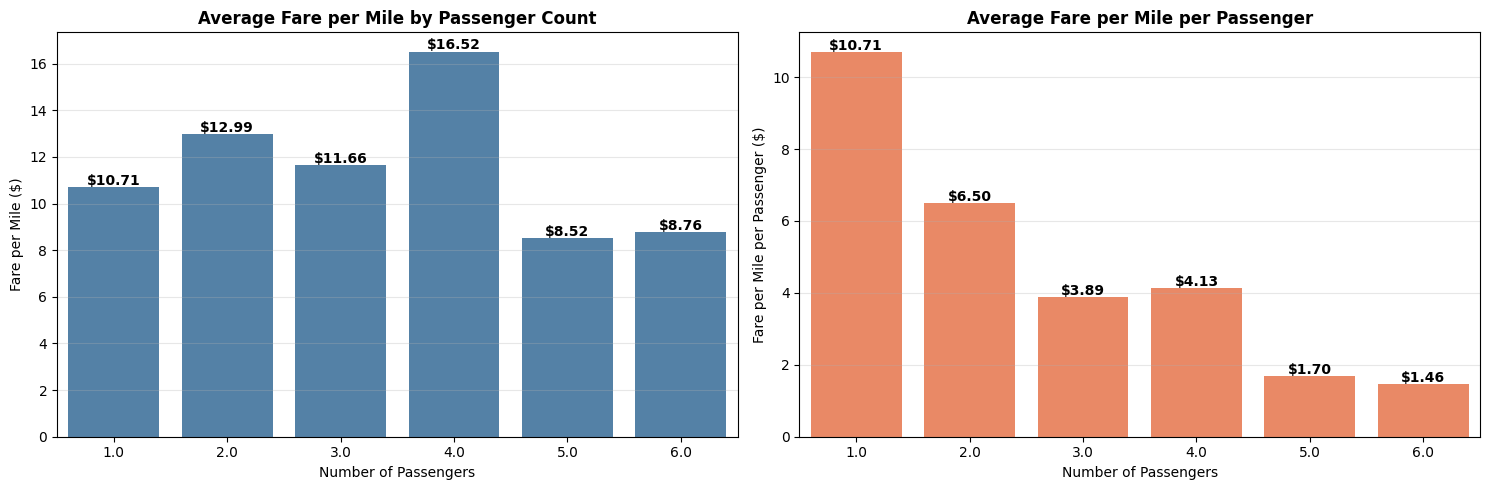

In [288]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Fare per mile (whole-trip cost)
sns.barplot(x=fare_analysis.index, y=fare_analysis['avg_fare_per_mile'], 
            ax=axes[0], color='steelblue')
axes[0].set_title('Average Fare per Mile by Passenger Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Passengers')
axes[0].set_ylabel('Fare per Mile ($)')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(fare_analysis['avg_fare_per_mile']):
    axes[0].text(i, v + 0.1, f'${v:.2f}', ha='center', fontweight='bold')

# Fare per mile per passenger (cost per person)
sns.barplot(x=fare_analysis.index, y=fare_analysis['avg_fare_per_mile_per_passenger'],
            ax=axes[1], color='coral')
axes[1].set_title('Average Fare per Mile per Passenger', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Passengers')
axes[1].set_ylabel('Fare per Mile per Passenger ($)')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(fare_analysis['avg_fare_per_mile_per_passenger']):
    axes[1].text(i, v + 0.05, f'${v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [289]:
# Compare the average fare per mile for different days and for different times of the day
df_merged = df_merged[df_merged['trip_distance'] > 0].copy()
df_merged['fare_per_mile'] = df_merged['fare_amount'] / df_merged['trip_distance']

# Get day name if not already present
df_merged['pickup_day_name'] = df_merged['tpep_pickup_datetime'].dt.day_name()


pickup_day_name
Monday      10.98
Tuesday     11.15
Wednesday   11.02
Thursday    11.09
Friday      11.06
Saturday    11.16
Sunday      11.78
Name: fare_per_mile, dtype: float64


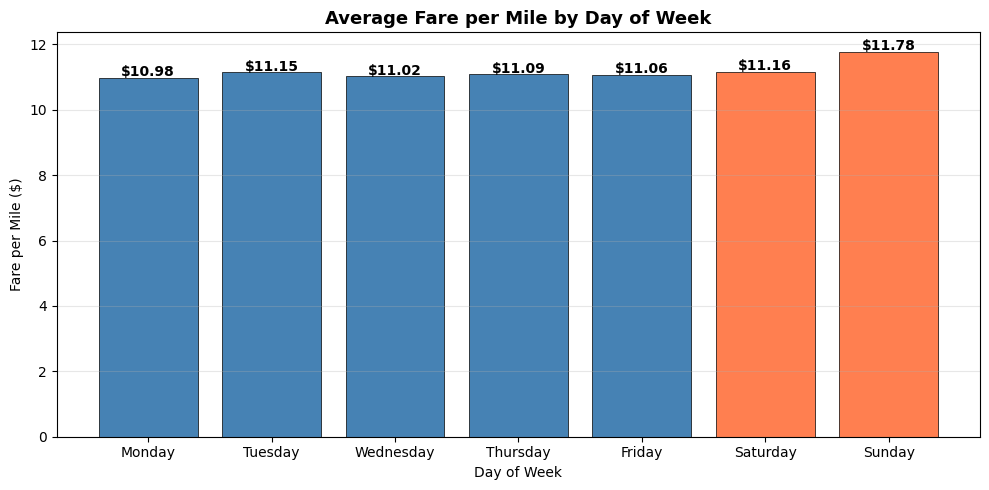

In [290]:
# Calculate average fare per mile by day
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
             'Friday', 'Saturday', 'Sunday']

fare_by_day = (df_merged.groupby('pickup_day_name')['fare_per_mile']
               .mean().reindex(day_order).round(2))

print(fare_by_day)

# Visualise
plt.figure(figsize=(10, 5))
colors = ['steelblue'] * 5 + ['coral'] * 2  # weekdays vs weekend
bars = plt.bar(fare_by_day.index, fare_by_day.values, color=colors, 
               edgecolor='black', linewidth=0.5)

# Add value labels on bars
for bar, val in zip(bars, fare_by_day.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05, 
             f'${val:.2f}', ha='center', fontweight='bold')

plt.title('Average Fare per Mile by Day of Week', fontsize=13, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Fare per Mile ($)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

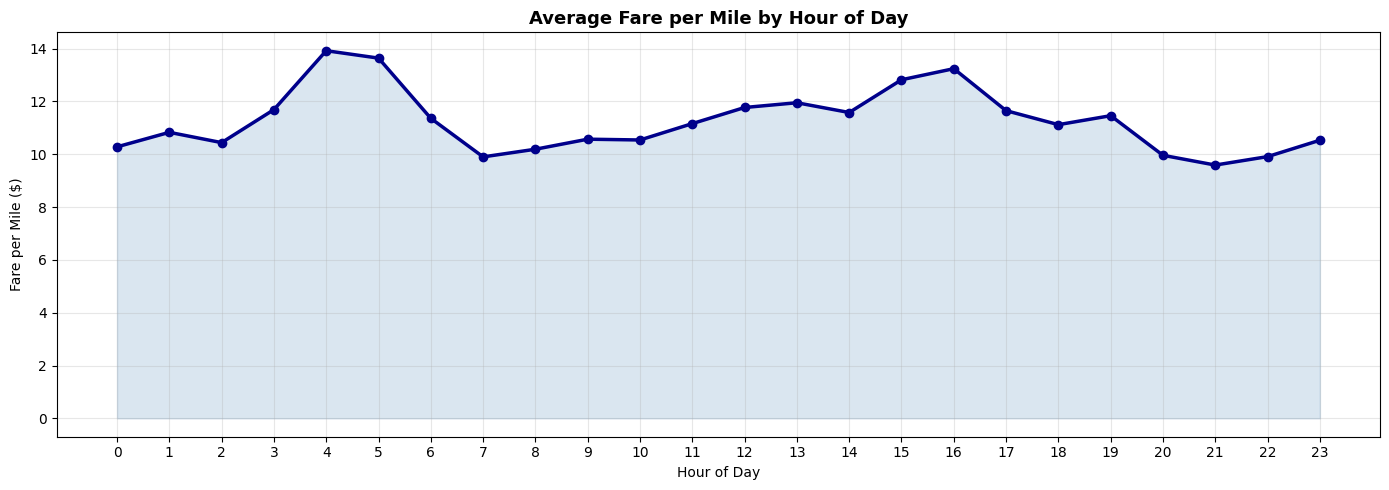

In [291]:
# Average fare per mile per hour
fare_by_hour = df_merged.groupby('pickup_hour')['fare_per_mile'].mean().round(2)

plt.figure(figsize=(14, 5))
plt.plot(fare_by_hour.index, fare_by_hour.values, 
         marker='o', linewidth=2.5, color='darkblue')
plt.fill_between(fare_by_hour.index, fare_by_hour.values, alpha=0.2, color='steelblue')

plt.title('Average Fare per Mile by Hour of Day', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Fare per Mile ($)')
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

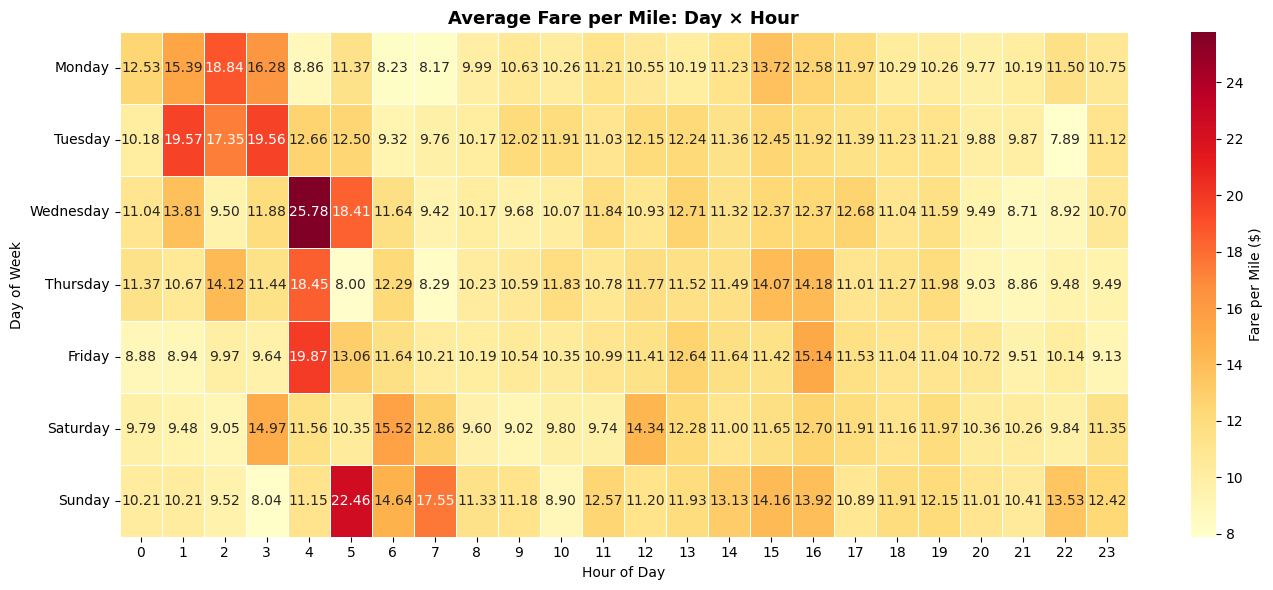

In [293]:
# Create pivot table: rows = day, cols = hour, values = avg fare per mile
fare_heatmap = (df_merged.groupby(['pickup_day_name', 'pickup_hour'])['fare_per_mile']
                .mean()
                .unstack()
                .reindex(day_order))

plt.figure(figsize=(14, 6))
sns.heatmap(fare_heatmap, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={'label': 'Fare per Mile ($)'}, 
            linewidths=0.5, linecolor='white')
plt.title('Average Fare per Mile: Day × Hour', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [295]:
# Compare fare per mile for different vendors

# Filter to trips with valid distance
valid_trips = df_merged.copy()

# Compute fare per mile
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

# Filter unrealistic values (outlier noise)
valid_trips = valid_trips[
    (valid_trips['fare_per_mile'] >= 1) & 
    (valid_trips['fare_per_mile'] <= 50)
]

# Summary stats per vendor
vendor_fare = valid_trips.groupby('VendorID').agg(
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    median_fare_per_mile=('fare_per_mile', 'median'),
    avg_fare=('fare_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    trip_count=('fare_per_mile', 'count')
).round(2)

# Add proportions
vendor_fare['trip_share_pct'] = (
    vendor_fare['trip_count'] / vendor_fare['trip_count'].sum() * 100
).round(2)

print(vendor_fare)

          avg_fare_per_mile  median_fare_per_mile  avg_fare  avg_distance  \
VendorID                                                                    
1                      7.82                  7.13     18.59          3.32   
2                      7.69                  7.11     19.98          3.60   

          trip_count  trip_share_pct  
VendorID                              
1             817270           25.10  
2            2438586           74.90  


**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [296]:
# Defining distance tiers

# Filter to valid trips and compute fare per mile
valid_trips = df_merged[df_merged['trip_distance'] > 0].copy()
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

# Remove outlier noise
valid_trips = valid_trips[
    (valid_trips['fare_per_mile'] >= 1) & 
    (valid_trips['fare_per_mile'] <= 50)
]

def distance_tier(distance):
    if distance <= 2:
        return 'Short (≤2 mi)'
    elif distance <= 5:
        return 'Medium (2-5 mi)'
    else:
        return 'Long (>5 mi)'

valid_trips['distance_tier'] = valid_trips['trip_distance'].apply(distance_tier)

In [297]:
tiered_comparison = valid_trips.groupby(['distance_tier', 'VendorID']).agg(
    avg_fare_per_mile=('fare_per_mile', 'mean'),
    median_fare_per_mile=('fare_per_mile', 'median'),
    avg_fare=('fare_amount', 'mean'),
    trip_count=('fare_per_mile', 'count')
).round(2).reset_index()

print(tiered_comparison)

     distance_tier  VendorID  avg_fare_per_mile  median_fare_per_mile  \
0     Long (>5 mi)         1               4.42                  4.26   
1     Long (>5 mi)         2               4.50                  4.31   
2  Medium (2-5 mi)         1               6.35                  6.10   
3  Medium (2-5 mi)         2               6.52                  6.24   
4    Short (≤2 mi)         1               9.44                  8.50   
5    Short (≤2 mi)         2               9.36                  8.52   

   avg_fare  trip_count  
0     48.87      131109  
1     50.98      437952  
2     18.96      216062  
3     19.16      677878  
4      9.98      470099  
5     10.13     1322756  


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [298]:
#  Analyze tip percentages based on distances, passenger counts and pickup times

# Tip percentage = (tip / fare) × 100
valid_trips = df_merged[
    (df_merged['fare_amount'] > 0) &       # avoid divide by zero
    (df_merged['payment_type'] == 1)        # IMPORTANT: card payments only
].copy()

valid_trips['tip_pct'] = (valid_trips['tip_amount'] / valid_trips['fare_amount']) * 100

# Filter unrealistic tip percentages (some are >100% due to data errors)
valid_trips = valid_trips[(valid_trips['tip_pct'] >= 0) & (valid_trips['tip_pct'] <= 100)]

print(f"Total card trips for tip analysis: {len(valid_trips):,}")
print(f"\nOverall average tip percentage: {valid_trips['tip_pct'].mean():.2f}%")
print(f"Median tip percentage: {valid_trips['tip_pct'].median():.2f}%")

Total card trips for tip analysis: 2,670,880

Overall average tip percentage: 24.69%
Median tip percentage: 25.82%


In [299]:
# Tip % by trip distance
# Bin distances into meaningful tiers
def distance_bucket(d):
    if d <= 1: return '1. ≤1 mi'
    elif d <= 3: return '2. 1-3 mi'
    elif d <= 5: return '3. 3-5 mi'
    elif d <= 10: return '4. 5-10 mi'
    elif d <= 20: return '5. 10-20 mi'
    else: return '6. >20 mi'

valid_trips['distance_bucket'] = valid_trips['trip_distance'].apply(distance_bucket)

tip_by_distance = valid_trips.groupby('distance_bucket').agg(
    avg_tip_pct=('tip_pct', 'mean'),
    median_tip_pct=('tip_pct', 'median'),
    trip_count=('tip_pct', 'count'),
    avg_fare=('fare_amount', 'mean')
).round(2)

print(tip_by_distance)

                 avg_tip_pct  median_tip_pct  trip_count  avg_fare
distance_bucket                                                   
1. ≤1 mi               30.46           31.40      566434      7.90
2. 1-3 mi              24.60           26.34     1331735     13.40
3. 3-5 mi              21.14           23.77      312227     22.57
4. 5-10 mi             20.98           22.96      228965     34.93
5. 10-20 mi            19.85           22.86      202398     61.88
6. >20 mi              17.86           21.18       29121     88.81


Insight:
Highest tip percentage is for shortest trips while long trips lead to lowest tips.
Possibly because short trips have smaller fares and people are comfortable paying extra tip.
While long trips already have high fare amount and people are not comfortable paying anything extra.

Tip % by passenger count

In [301]:
tip_by_passenger = valid_trips.groupby('passenger_count').agg(
    avg_tip_pct=('tip_pct', 'mean'),
    median_tip_pct=('tip_pct', 'median'),
    trip_count=('tip_pct', 'count')
).round(2)

# Filter for meaningful sample sizes
tip_by_passenger = tip_by_passenger[tip_by_passenger['trip_count'] >= 100]
print(tip_by_passenger)

                 avg_tip_pct  median_tip_pct  trip_count
passenger_count                                         
1.00                   24.76           25.88     2066566
2.00                   24.51           25.43      400171
3.00                   24.26           25.42       96379
4.00                   23.98           25.37       48186
5.00                   24.97           25.93       35865
6.00                   24.90           25.93       23713


In [302]:
# Tip % by pickup hour
tip_by_hour = valid_trips.groupby('pickup_hour').agg(
    avg_tip_pct=('tip_pct', 'mean'),
    median_tip_pct=('tip_pct', 'median'),
    trip_count=('tip_pct', 'count')
).round(2)

print(tip_by_hour)

             avg_tip_pct  median_tip_pct  trip_count
pickup_hour                                         
0                  23.98           25.65       76338
1                  23.86           25.65       51471
2                  23.79           25.88       33519
3                  23.67           25.86       21197
4                  22.95           25.00       12521
5                  22.99           24.47       13283
6                  22.78           24.52       34973
7                  23.45           25.13       73210
8                  23.67           25.13      102910
9                  24.02           25.32      113853
10                 24.20           25.37      120162
11                 24.12           25.32      130174
12                 24.08           25.25      140657
13                 24.03           25.13      144630
14                 23.87           25.13      156173
15                 23.75           24.93      160944
16                 25.70           26.57      

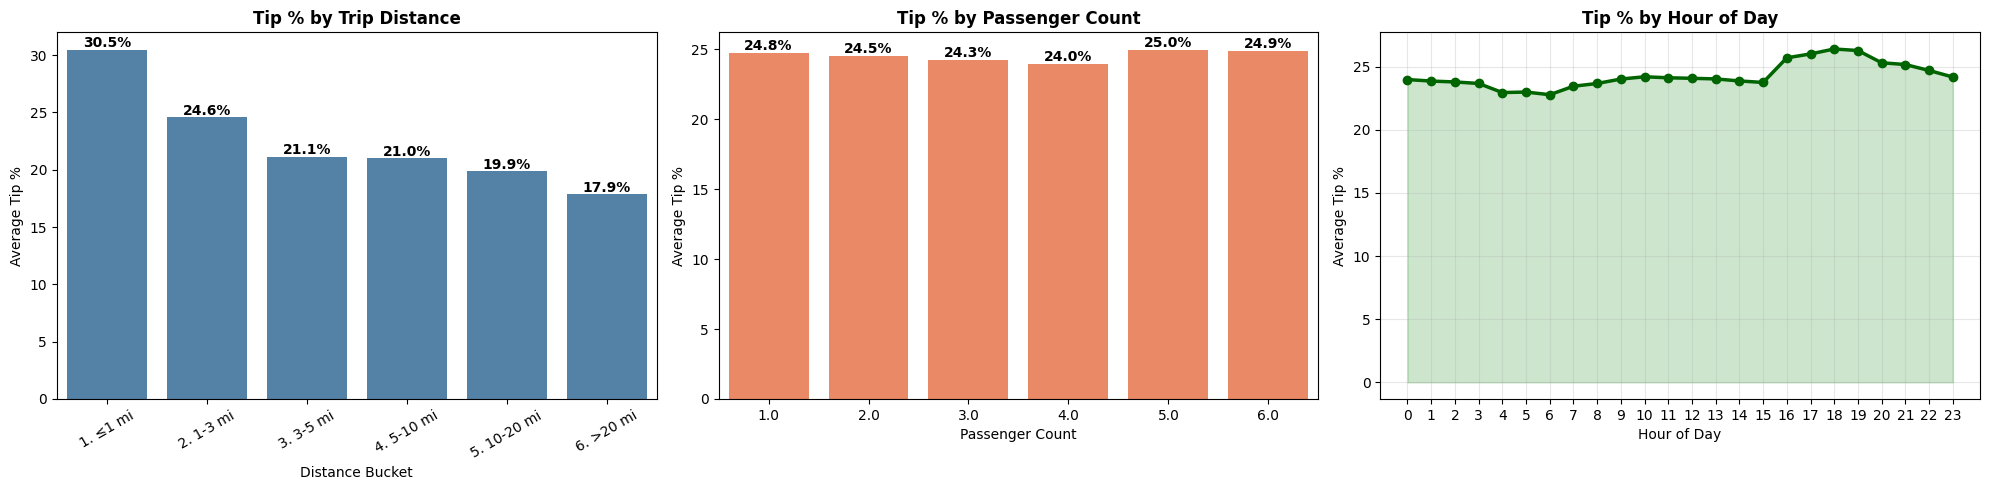

In [303]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# By distance
sns.barplot(x=tip_by_distance.index, y=tip_by_distance['avg_tip_pct'], 
            ax=axes[0], color='steelblue')
axes[0].set_title('Tip % by Trip Distance', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Distance Bucket')
axes[0].set_ylabel('Average Tip %')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(tip_by_distance['avg_tip_pct']):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# By passenger count
sns.barplot(x=tip_by_passenger.index, y=tip_by_passenger['avg_tip_pct'],
            ax=axes[1], color='coral')
axes[1].set_title('Tip % by Passenger Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Passenger Count')
axes[1].set_ylabel('Average Tip %')
for i, v in enumerate(tip_by_passenger['avg_tip_pct']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# By hour
axes[2].plot(tip_by_hour.index, tip_by_hour['avg_tip_pct'], 
             marker='o', linewidth=2.5, color='darkgreen')
axes[2].fill_between(tip_by_hour.index, tip_by_hour['avg_tip_pct'], alpha=0.2, color='green')
axes[2].set_title('Tip % by Hour of Day', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Average Tip %')
axes[2].set_xticks(range(24))
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [304]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%

# Use only card payments (cash tips aren't recorded)
card_trips = df_merged[
    (df_merged['fare_amount'] > 0) & 
    (df_merged['payment_type'] == 1)
].copy()

card_trips['tip_pct'] = (card_trips['tip_amount'] / card_trips['fare_amount']) * 100

# Filter out unrealistic tip percentages
card_trips = card_trips[(card_trips['tip_pct'] >= 0) & (card_trips['tip_pct'] <= 100)]

# Create the two groups
low_tip = card_trips[card_trips['tip_pct'] < 10].copy()
high_tip = card_trips[card_trips['tip_pct'] > 25].copy()

print(f"Low tip trips (<10%):  {len(low_tip):,} ({len(low_tip)/len(card_trips)*100:.1f}%)")
print(f"High tip trips (>25%): {len(high_tip):,} ({len(high_tip)/len(card_trips)*100:.1f}%)")
print(f"Trips in between (10-25%): {len(card_trips) - len(low_tip) - len(high_tip):,}")

Low tip trips (<10%):  257,400 (9.6%)
High tip trips (>25%): 1,465,527 (54.9%)
Trips in between (10-25%): 947,953


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [305]:
# How does passenger count vary across zones
pass_by_hour = df_merged.groupby('pickup_hour')['passenger_count'].agg(
    avg_passengers='mean',
    median_passengers='median',
    trip_count='count'
).round(2)

print(pass_by_hour)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 
             'Friday', 'Saturday', 'Sunday']

# Make sure pickup_day_name exists
df_merged['pickup_day_name'] = df_merged['tpep_pickup_datetime'].dt.day_name()

pass_by_day = df_merged.groupby('pickup_day_name')['passenger_count'].agg(
    avg_passengers='mean',
    median_passengers='median',
    trip_count='count'
).round(2).reindex(day_order)

print(pass_by_day)


             avg_passengers  median_passengers  trip_count
pickup_hour                                               
0                      1.43               1.00       90937
1                      1.44               1.00       60847
2                      1.46               1.00       39912
3                      1.45               1.00       25910
4                      1.41               1.00       16430
5                      1.31               1.00       17701
6                      1.26               1.00       43973
7                      1.28               1.00       88038
8                      1.30               1.00      122680
9                      1.32               1.00      139874
10                     1.36               1.00      152339
11                     1.37               1.00      165316
12                     1.38               1.00      178996
13                     1.39               1.00      184594
14                     1.40               1.00      1980

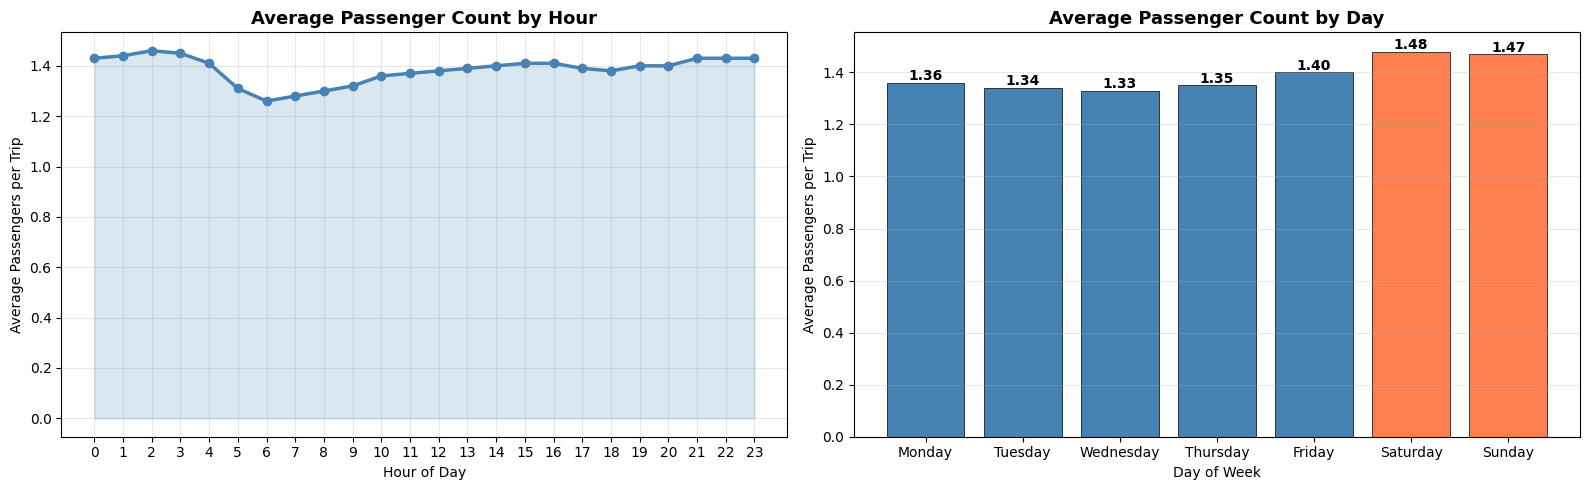

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average passengers by hour
axes[0].plot(pass_by_hour.index, pass_by_hour['avg_passengers'], 
             marker='o', linewidth=2.5, color='steelblue')
axes[0].fill_between(pass_by_hour.index, pass_by_hour['avg_passengers'], 
                     alpha=0.2, color='steelblue')
axes[0].set_title('Average Passenger Count by Hour', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Passengers per Trip')
axes[0].set_xticks(range(24))
axes[0].grid(alpha=0.3)

# Average passengers by day
colors = ['steelblue'] * 5 + ['coral'] * 2  # weekday vs weekend
bars = axes[1].bar(pass_by_day.index, pass_by_day['avg_passengers'], 
                    color=colors, edgecolor='black', linewidth=0.5)
axes[1].set_title('Average Passenger Count by Day', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Average Passengers per Trip')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for bar, val in zip(bars, pass_by_day['avg_passengers']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.01, 
                 f'{val:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

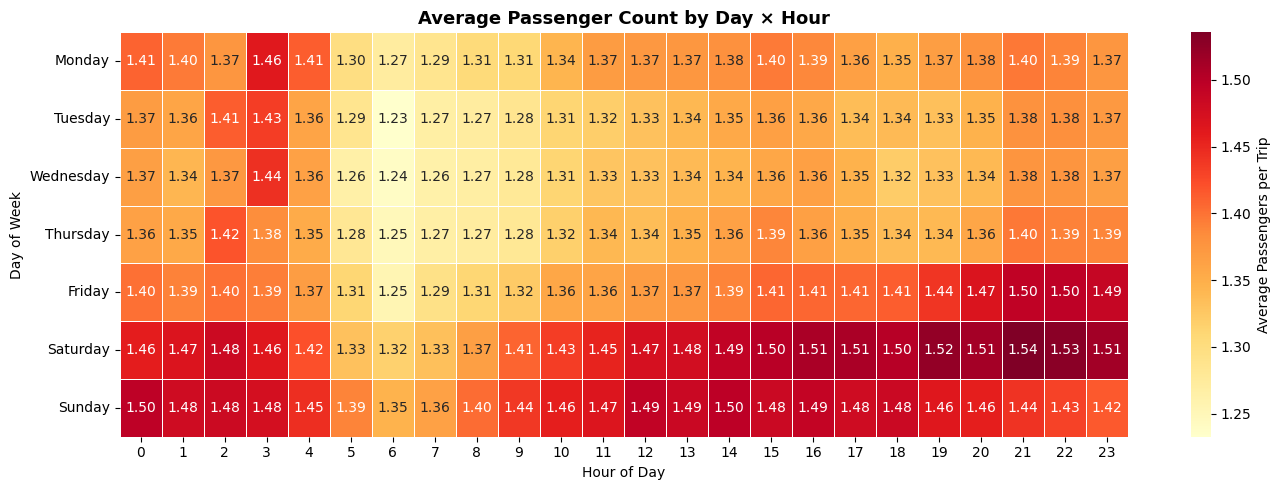

In [307]:
# Create a heatmap to show the average passenger count for each day of the week and hour of the day
heatmap_data = (df_merged.groupby(['pickup_day_name', 'pickup_hour'])['passenger_count']
                .mean()
                .unstack()
                .reindex(day_order))

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='.2f',
            cbar_kws={'label': 'Average Passengers per Trip'},
            linewidths=0.5)
plt.title('Average Passenger Count by Day × Hour', fontsize=13, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [308]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

# Group by pickup LocationID and calculate the average passenger count
avg_passengers_by_zone = (df_merged.groupby('LocationID')['passenger_count']
                          .mean()
                          .reset_index(name='avg_passengers')
                          .round(2))

print(avg_passengers_by_zone.head())

# Merge into the existing zones_with_trips GeoDataFrame
zones_with_trips = zones_with_trips.merge(
    avg_passengers_by_zone,
    on='LocationID',
    how='left'
)

# Fill NaN for zones with no trips
zones_with_trips['avg_passengers'] = zones_with_trips['avg_passengers'].fillna(0)

print(zones_with_trips.head())
print(f"\nShape: {zones_with_trips.shape}")

   LocationID  avg_passengers
0        1.00            1.53
1        2.00            1.00
2        3.00            1.05
3        4.00            1.44
4        5.00            1.00
   OBJECTID  Shape_Leng  Shape_Area                     zone  LocationID  \
0         1        0.12        0.00           Newark Airport           1   
1         2        0.43        0.00              Jamaica Bay           2   
2         3        0.08        0.00  Allerton/Pelham Gardens           3   
3         4        0.04        0.00            Alphabet City           4   
4         5        0.09        0.00            Arden Heights           5   

         borough                                           geometry  \
0            EWR  POLYGON ((933100.918 192536.086, 933091.011 19...   
1         Queens  MULTIPOLYGON (((1033269.244 172126.008, 103343...   
2          Bronx  POLYGON ((1026308.77 256767.698, 1026495.593 2...   
3      Manhattan  POLYGON ((992073.467 203714.076, 992068.667 20...   
4  State

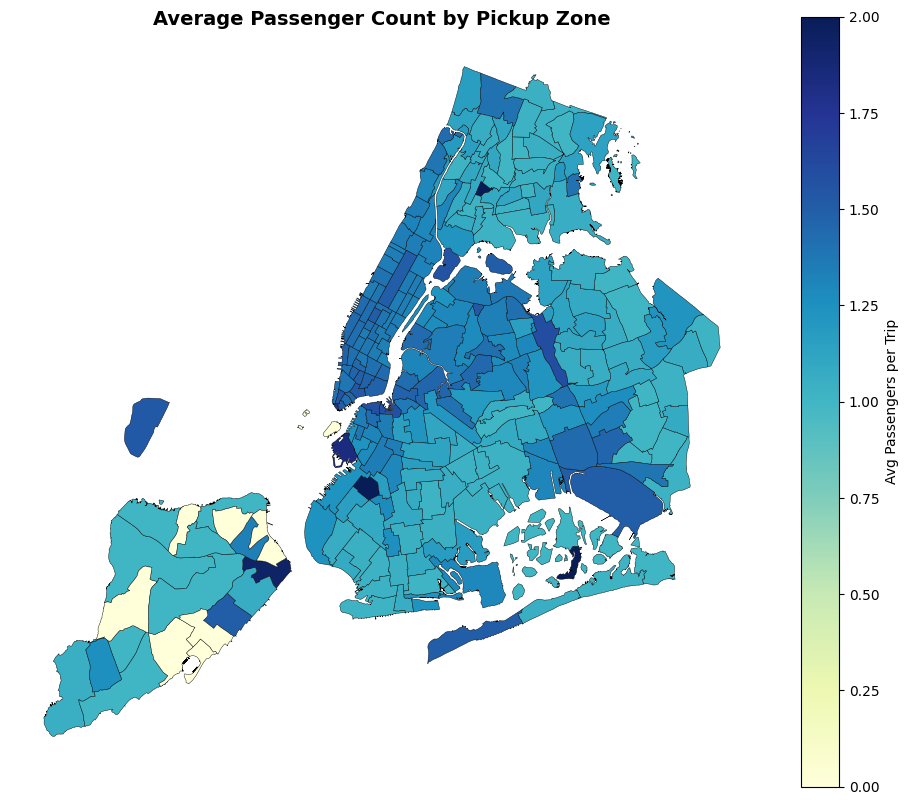

In [309]:
# Choropeth map
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trips.plot(
    column='avg_passengers',
    ax=ax,
    legend=True,
    cmap='YlGnBu',
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'label': 'Avg Passengers per Trip', 'orientation': 'vertical'},
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Average Passenger Count by Pickup Zone', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.show()

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.